# 08 · Hybrid Downscaling — Climate Change Scenarios

**Author:** Salvador Navas  
**Basin:** Río Besaya — Cantabria

## What this notebook does

This notebook applies the **full hybrid downscaling methodology** to quantify how 
flood hazard in the Besaya basin changes under CMIP5 climate change scenarios 
(RCP4.5 and RCP8.5, horizon 2041–2070) relative to the historical control period.

**The problem:** We need future flood maps, but:
- Future observed streamflow doesn't exist
- GCM/RCM outputs are biased and too coarse for hydraulic modelling
- Running a fully coupled climate–hydrological–hydraulic chain is computationally 
  expensive for many models

**The hybrid solution:**
1. **Delta factors** — scale historical design storms (IDF curves) by the ratio of 
   future to control 24h precipitation from bias-corrected CORDEX models
2. **Event selection** — use the existing synthetic event library (Notebook 06) 
   to translate scaled design depths into complete flood hydrographs
3. **Map interpolation** — use the pre-computed HEC-RAS flood map library (Notebook 07) 
   to reconstruct inundation maps for all synthetic events without running HEC-RAS again

## Scenarios and data
- **RCP4.5** (intermediate) — horizon 2041–2070
- **RCP8.5** (high-emissions legacy scenario) — horizon 2041–2070
- Source: CORDEX-CMIP5 ensemble (10 models per scenario)

## Complete workflow

```
CORDEX-CMIP5 pre-computed series (RCP4.5/8.5)
         ↓
Bias correction / delta-change diagnostics when reference data are available
         ↓
GEV over future period → scenario delta factors
         ↓
Event selection (FloodEventSelector: threshold → PCA → copula)
         ↓
HMS/RAS workflow hooks or analytical fallbacks in release mode
         ↓
Flood-map interpolation when a full hydraulic map library exists
```


In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, warnings
warnings.filterwarnings('ignore')

from pyhydra.data_sources.climate_change.copernicus import download_CDS_CMIP6
from pyhydra.climate.bias_correction.quantile import BiasCorrection
from pyhydra.climate.bias_correction.delta import delta_method
from pyhydra.climate.time_series.extremes import (
    extract_block_maxima, fit_gev, return_levels,
)
from pyhydra.climate.hybrid_downscaling import (
    FloodEventSelector,
    HydrographReconstructor,
    pixel_return_period,
    DEFAULT_RETURN_PERIODS,
)
from pyhydra.modeling.hydrology.hec_hms import (
    read_basin, generate_gage, fill_gage,
    generate_met, generate_control, generate_run, generate_py,
    run_hms_script, read_dss6_timeseries, read_hms_dss_timeseries,
)
from pyhydra.modeling.hydraulic.hec_ras import (
    modify_unsteady_file, modify_plan_file,
    create_flow_series, run_hec_ras,
)

# ── Rutas ──────────────────────────────────────────────────────────────────────
_cwd = Path.cwd()
_candidates = [Path('/workspace'), _cwd, *_cwd.parents]
REPO_ROOT = next(
    (p for p in _candidates if (p / 'notebooks').exists() or (p / 'pyhydra').exists()),
    _cwd,
)
DATA_DIR   = Path(os.environ.get('HYDRA_DATA_DIR',  str(REPO_ROOT / 'data')))
TOOLS_DIR  = Path(os.environ.get('HYDRA_TOOLS_DIR', str(REPO_ROOT / 'tools')))
DATA_ROOT  = DATA_DIR / 'pilot_cases' / 'los_corrales_buelna'


def _hydra_session_root() -> Path:
    env_root = os.environ.get('HYDRA_SESSION_DIR') or os.environ.get('HYDRA_RUNTIME_DIR')
    if env_root:
        return Path(env_root)
    cwd = Path.cwd().resolve()
    for p in (cwd, *cwd.parents):
        if p.name == 'notebooks':
            return p.parent
    return cwd / '.hydra_runtime'

SESSION_ROOT = _hydra_session_root()
SESSION_DATA_ROOT = SESSION_ROOT / 'data' / 'pilot_cases' / 'los_corrales_buelna'
PROC_OUT_DIR = SESSION_DATA_ROOT / 'processed'
PROC_OUT_DIR.mkdir(parents=True, exist_ok=True)

def _session_or_shared(relative_path: str | Path) -> Path:
    session_path = SESSION_DATA_ROOT / relative_path
    shared_path = DATA_ROOT / relative_path
    if session_path.exists():
        return session_path
    if shared_path.exists():
        return shared_path
    return session_path

PROC_DIR   = DATA_ROOT / 'processed'
SOURCE_HMS_DIR = DATA_ROOT / 'models' / 'hec_hms'
SOURCE_RAS_DIR = DATA_ROOT / 'models' / 'hec_ras'
HMS_DIR    = SESSION_DATA_ROOT / 'models' / 'hec_hms'
RAS_DIR    = SESSION_DATA_ROOT / 'models' / 'hec_ras'
if SOURCE_HMS_DIR.exists() and not HMS_DIR.exists():
    HMS_DIR.parent.mkdir(parents=True, exist_ok=True)
    shutil.copytree(SOURCE_HMS_DIR, HMS_DIR)
if SOURCE_RAS_DIR.exists() and not RAS_DIR.exists():
    RAS_DIR.parent.mkdir(parents=True, exist_ok=True)
    shutil.copytree(SOURCE_RAS_DIR, RAS_DIR)
CC_DIR     = DATA_ROOT / 'climate_change'
SHARED_OUT_DIR = PROC_DIR / 'cc_scenarios'
OUT_DIR    = PROC_OUT_DIR / 'cc_scenarios'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Binary tools — override via env vars or HYDRA_TOOLS_DIR
HEC_HMS_BIN = Path(os.environ.get('HEC_HMS_BIN',
    str(TOOLS_DIR / 'hms' / 'HEC-HMS-4.13' / 'hec-hms.sh')))
HEC_RAS_BIN = Path(os.environ.get('HEC_RAS_BIN',
    str(TOOLS_DIR / 'ras' / 'RAS_6.5' / 'RasUnsteady.exe')))

NAME_MODEL  = 'Project_1'
NAME_BASIN  = 'Modelo_Besaya'
PATH_MODEL  = str(HMS_DIR)
TIME_STEP   = 60   # minutos

BBOX = {'lat_min': 42.9, 'lat_max': 43.4, 'lon_min': -4.3, 'lon_max': -3.8}

RETURN_PERIODS = list(DEFAULT_RETURN_PERIODS)
SCENARIOS      = ['rcp45', 'rcp85']
CMIP6_SSPS     = SCENARIOS
N_TYPES        = 9
SSP_MAP        = {'rcp45': 'RCP4.5', 'rcp85': 'RCP8.5',
                  'ssp245': 'SSP2-4.5', 'ssp585': 'SSP5-8.5'}

print('Configuración lista')
RUN_MODELS = os.getenv('HYDRA_RUN_MODELS', '0') == '1'
print(f'Run external HMS/RAS models: {RUN_MODELS}')

RUN_RASTER_INTERPOLATION = os.getenv('HYDRA_RUN_RASTER_INTERPOLATION', '0') == '1'
print(f'Run raster return-period interpolation: {RUN_RASTER_INTERPOLATION}')

Configuración lista
Run external HMS/RAS models: False
Run raster return-period interpolation: False


---
## 1. CORDEX-CMIP5 data download (optional)

The climate change data used here come from the **CORDEX-CMIP5** project (Coordinated
Regional Downscaling Experiment) under the **RCP4.5** and **RCP8.5** scenarios of the
IPCC AR5 report.

**Why CORDEX-CMIP5 and not CMIP6?**  
At the time of this pilot case study (2021–2023), CORDEX-EUR-11 was the highest 
resolution regional downscaling available for Spain (~12 km grid). CMIP6 global 
models exist but were not yet regionally downscaled at fine resolution for the 
Iberian Peninsula at study time. Future updates should use EURO-CORDEX at CMIP6.

**Why 10 models?**  
The CORDEX ensemble spans multiple driving GCMs (EC-EARTH, HadGEM2, MPI-ESM-LR, etc.) 
and regional models (RACMO, RCA4, RegCM4, etc.). Using 10 models captures a 
significant fraction of the model uncertainty. The ensemble spread in delta factors 
directly becomes the uncertainty estimate for the CC impact analysis.

> **Pre-computed:** `processed/cc_hms_results/` contains the streamflow series  
> simulated by HEC-HMS for 10 models × 2 scenarios × 3 horizons.  
> Delta factors are computed directly from these series.

To download fresh CORDEX data from the ESGF or Copernicus portal:
```python
# from pyhydra.data_sources.climate_change.copernicus import download_CDS_CMIP5
# download_CDS_CMIP5(models=[...], experiments=['historical','rcp45','rcp85'], ...)
```


In [2]:
# ── Pre-computed CC series (CORDEX: 10 models × 2 RCP × 3 horizons) ───────
CC_HMS_DIR = DATA_ROOT / 'processed' / 'cc_hms_results'

HORIZONTE  = '2041_2070'   # options: 2011_2040, 2041_2070, 2071_2100
SCENARIOS  = ['rcp45', 'rcp85']

cc_series = {ssp: {} for ssp in SCENARIOS}

for ssp in SCENARIOS:
    pattern = f'Caudal_*_{ssp.replace("rcp","rcp")}_{HORIZONTE}.csv'
    files   = sorted(CC_HMS_DIR.glob(pattern.replace('rcp', '*r1i1p1_rcp')
                                            .replace(f'_rcp_{HORIZONTE}', f'_{ssp}_{HORIZONTE}')))
    # Actual pattern: Caudal_MODEL_r1i1p1_rcpXX_YYYY_ZZZZ.csv
    files = sorted(CC_HMS_DIR.glob(f'Caudal_*_r1i1p1_{ssp}_{HORIZONTE}.csv'))
    for f in files:
        model = f.stem.split('_r1i1p1_')[0].replace('Caudal_', '')
        df    = pd.read_csv(f, index_col=0, parse_dates=True)
        cc_series[ssp][model] = df.iloc[:, 0].rename(model)
    print(f'{ssp.upper()} {HORIZONTE}: {len(cc_series[ssp])} modelos — '
          f'{list(cc_series[ssp].keys())}')

# ── CMIP6 download (alternative if no pre-computed CORDEX data) ─────────────────
# If you need to download fresh data from Copernicus CDS:
# from pyhydra.data_sources.climate_change.copernicus import download_CDS_CMIP6
# download_CDS_CMIP6(models=[...], experiments=['historical','ssp245','ssp585'],
#                    variable='pr', temporal_resolution='daily', ...)
# ───────────────────────────────────────────────────────────────────────────────

# Ensemble statistics
for ssp in SCENARIOS:
    if cc_series[ssp]:
        ens = pd.DataFrame(cc_series[ssp])
        print(f'\n{ssp.upper()} — Qmed ensamble: '
              f'{ens.mean().mean():.2f} m³/s  '
              f'Qmax ensamble: {ens.max().max():.2f} m³/s')

RCP45 2041_2070: 11 modelos — ['ACCESS1-0', 'CMCC-CM', 'CNRM-CM5', 'CSIRO-Mk3-6-0', 'CanESM2', 'HadGEM2-ES', 'INM-CM4', 'IPSL-CM5A-MR', 'MIROC5', 'MPI-ESM-LR', 'NorESM1-M']
RCP85 2041_2070: 11 modelos — ['ACCESS1-0', 'CMCC-CM', 'CNRM-CM5', 'CSIRO-Mk3-6-0', 'CanESM2', 'HadGEM2-ES', 'INM-CM4', 'IPSL-CM5A-MR', 'MIROC5', 'MPI-ESM-LR', 'NorESM1-M']

RCP45 — Qmed ensamble: 12.64 m³/s  Qmax ensamble: 361.58 m³/s

RCP85 — Qmed ensamble: 12.41 m³/s  Qmax ensamble: 380.33 m³/s


---
## 2. Load and pre-process CMIP5 series

The CMIP5 streamflow series (`cc_hms_results/`) were produced by running HEC-HMS 
with CORDEX precipitation as the forcing input — one series per model per scenario.

**Important limitation:**  
These series use the **uncalibrated HMS model** (same CN/Tc as Notebook 04). 
Direct GEV fitting on these series would yield unrealistically high future 
quantiles. This is why **the delta-factor approach is preferred** over fitting 
GEV to the raw CORDEX streamflow series.

Variables loaded per model:
- Historical period: 1971–2000 (or 1976–2005 depending on model availability)
- Future period: 2041–2070 (mid-century horizon)
- Units: m³/s (metric output from HMS)


In [3]:
try:
    import xarray as xr
    HAS_XARRAY = True
except ImportError:
    HAS_XARRAY = False
    print('xarray no instalado → pip install xarray')

# Paths to raw CMIP5 netCDF data — only if downloaded previously
cc_raw_dir   = CC_DIR / 'cmip6_raw'
CMIP6_MODELS = ['MPI-ESM1-2-HR', 'EC-Earth3', 'CNRM-CM6-1-HR']
PERIOD_HIST  = ('1981-01-01', '2010-12-31')
PERIOD_FUT   = ('2041-01-01', '2070-12-31')

def load_cmip6_series(nc_dir: Path, model: str, experiment: str):
    """Carga la serie de precipitación diaria (mm/día) para un modelo y escenario."""
    if not HAS_XARRAY or not nc_dir.exists():
        return None
    files = list(nc_dir.glob(f'*{model}*{experiment}*pr*.nc'))
    if not files:
        return None
    ds = xr.open_mfdataset(files, combine='by_coords')
    lat_c = (BBOX['lat_min'] + BBOX['lat_max']) / 2
    lon_c = (BBOX['lon_min'] + BBOX['lon_max']) / 2
    pr = ds['pr'].sel(lat=lat_c, lon=lon_c, method='nearest')
    series = pd.Series(
        (pr.values * 86400).clip(0),
        index=pd.DatetimeIndex(pr.time.values),
        name=f'{model}_{experiment}',
    )
    return series

# Load historical and future series for each model (if nc files exist)
cmip6_hist = {}
cmip6_fut  = {ssp: {} for ssp in CMIP6_SSPS}

if cc_raw_dir.exists() and HAS_XARRAY:
    for model in CMIP6_MODELS:
        s_hist = load_cmip6_series(cc_raw_dir, model, 'historical')
        if s_hist is not None:
            cmip6_hist[model] = s_hist.loc[PERIOD_HIST[0]:PERIOD_HIST[1]]

        for ssp in CMIP6_SSPS:
            experiment = ssp.replace('rcp', 'ssp').replace('45', '245').replace('85', '585')
            s_fut = load_cmip6_series(cc_raw_dir, model, experiment)
            if s_fut is not None:
                cmip6_fut[ssp][model] = s_fut.loc[PERIOD_FUT[0]:PERIOD_FUT[1]]

    print(f'Modelos históricos cargados: {list(cmip6_hist.keys())}')
else:
    print('Datos CMIP6 crudos no disponibles — se usarán series CORDEX pre-calculadas')
    print('Para descargar: pyhydra.data_sources.climate_change.copernicus.download_CDS_CMIP6')

Datos CMIP6 crudos no disponibles — se usarán series CORDEX pre-calculadas
Para descargar: pyhydra.data_sources.climate_change.copernicus.download_CDS_CMIP6


---
## 3. Bias correction — Quantile Mapping

Bias correction adjusts the probability distribution of the historical model
to match that of the observations. The same adjustment is applied to the future
period (QM delta change method).

**Why QM (Quantile Mapping) and not simple bias removal?**

| Method | Corrects | Does not correct |
|--------|---------|-----------------|
| **Additive scaling** | Mean bias | Distributional shape, extremes |
| **Multiplicative scaling** | Mean ratio | Distributional shape, extremes |
| **Quantile Mapping** | Full CDF, including extremes | Temporal sequencing |
| **QDM** (Quantile Delta Mapping) | Full CDF + preserves trends | More complex |

QM is used here because the main goal is to correct the extreme precipitation 
quantiles (99th percentile) that drive flood events. Additive/multiplicative 
scaling would only correct the mean.

> **Note on QM for future periods:** QM applied to future series can clip values 
> outside the historical training range. QDM (Notebook `bias_correction`) is 
> preferred when future values are expected to exceed the historical maximum.
> Here we use QM as a diagnostic tool, not as the primary methodology.


In [4]:
# Observed reference series
rain_obs = pd.read_csv(_session_or_shared('processed/rain_daily.csv'), index_col=0, parse_dates=True)
pma_obs  = rain_obs.mean(axis=1).dropna()
pma_hist_obs = pma_obs.loc[PERIOD_HIST[0]:PERIOD_HIST[1]]

bc_series = {ssp: {} for ssp in CMIP6_SSPS}

if cmip6_hist:
    bc = BiasCorrection()
    for model, s_hist_model in cmip6_hist.items():
        common = pma_hist_obs.index.intersection(s_hist_model.index)
        if len(common) < 365:
            continue
        obs_arr  = pma_hist_obs.loc[common].values
        hist_arr = s_hist_model.loc[common].values
        for ssp in CMIP6_SSPS:
            if model not in cmip6_fut[ssp]:
                continue
            fut_arr = cmip6_fut[ssp][model].values
            try:
                corrected = bc.correct(obs=obs_arr, hist_model=hist_arr,
                                       fut_model=fut_arr, variable='pr')
                bc_series[ssp][model] = pd.Series(
                    corrected.clip(0),
                    index=cmip6_fut[ssp][model].index,
                    name=f'{model}_{ssp}_bc',
                )
                print(f'  {model} {ssp}: QM OK')
            except Exception as e:
                print(f'  {model} {ssp}: QM error — {e}')
else:
    print('Sin datos CMIP6 — usando series CORDEX pre-calculadas como bc_series')
    for ssp in CMIP6_SSPS:
        for model, s in cc_series[ssp].items():
            bc_series[ssp][model] = s

Sin datos CMIP6 — usando series CORDEX pre-calculadas como bc_series


In [5]:
# ── IDF extreme-value parameters (saved by NB04) ──────────────────────────────
EV_PARAMS_FILE = _session_or_shared('processed/extreme_value_params.json')
if EV_PARAMS_FILE.exists():
    import json as _json
    with open(EV_PARAMS_FILE) as _f:
        ev_params = _json.load(_f)
    print(f'ev_params cargado: {EV_PARAMS_FILE.name}')
else:
    # Minimal fallback so the notebook continues even without NB04 outputs
    ev_params = {
        'idf_temez_exponent': 0.28,
        'return_levels_24h': {'2':48.4,'5':58.2,'10':64.8,'25':73.5,
                              '50':80.1,'100':86.8,'500':102.8},
    }
    print(f'WARNING: {EV_PARAMS_FILE} no encontrado — usando valores hardcoded')

T_ref = sorted(int(k) for k in ev_params['return_levels_24h'])
print(f'Períodos de retorno de diseño: {T_ref}')
print(f'Exponente IDF Témez: {ev_params["idf_temez_exponent"]}')
print(f'P24h control: { {T: ev_params["return_levels_24h"][str(T)] for T in T_ref} }')


ev_params cargado: extreme_value_params.json
Períodos de retorno de diseño: [2, 5, 10, 25, 50, 100, 500]
Exponente IDF Témez: 0.28
P24h control: {2: 45.3, 5: 54.4, 10: 60.1, 25: 67.1, 50: 72.0, 100: 76.8, 500: 87.2}


---
## 4. Climate-change delta factors — IDF-based ratio (P₂₄ₕ CC / P₂₄ₕ control)

The correct procedure for computing precipitation delta factors is to compare
the **total 24-hour design depth** from the CC IDF curves with that of the
observed control IDF. The CC IDF curves are already available as pre-computed
regional downscaling products (CORDEX precipitation → statistical downscaling →
alternating-block hyetograms, one per CORDEX model ensemble mean).

**Delta factor definition:**
$$\delta_T = 
rac{P_{24h,CC}(T)}{P_{24h,ctrl}(T)}$$

where P₂₄ₕ,ctrl(T) comes from the observed GEV (Notebook 03) and 
P₂₄ₕ,CC(T) from the bias-corrected CORDEX GEV for the same return period T.

**Interpreting the ensemble spread:**

| δT range | Implication |
|----------|-------------|
| δT = 1.0 | No change — climate model shows no signal |
| δT = 1.10–1.20 | +10–20% precipitation → ~+5–15% peak flow increase |
| δT > 1.25 | Strong signal; climate change dominates uncertainty |
| Wide spread (±0.15) | Model uncertainty > signal; use ensemble median |

> **Why NOT the CORDEX streamflow GEV approach?**  
> GEV fits to uncalibrated HMS streamflow series produce implausibly large 
> future quantiles because HMS overestimates peaks by 5–10× (uncalibrated CN). 
> The IDF-delta approach bypasses this by working in the precipitation space 
> where CORDEX models have been validated.


In [6]:
# ── Load pre-computed CC delta factors from Notebook 04 ───────────────────────
# Computed as P_cc(24h) / P_ctrl(24h) from CORDEX statistical downscaling.
# File regenerated by NB04 with the corrected computation (ratio at 24h row).
DELTA_FILE = _session_or_shared(Path('processed') / 'hms_events' / f'delta_factors_{HORIZONTE}.csv')
HIET_CC_DIR = DATA_ROOT / 'gauges' / 'rainfall' / 'Hietogramas' / 'Cambio_Climatico'

delta_calibrated = {ssp: {} for ssp in SCENARIOS}

if DELTA_FILE.exists():
    delta_df_loaded = pd.read_csv(DELTA_FILE)
    for _, row in delta_df_loaded.iterrows():
        ssp = row['escenario']
        T   = int(row['T_years'])
        if ssp in delta_calibrated and not pd.isna(row['delta']):
            delta_calibrated[ssp][T] = float(row['delta'])
    print(f'Factores delta cargados desde {DELTA_FILE.name}')
else:
    # Recompute if CSV is absent (same logic as NB04)
    print('delta_factors CSV no encontrado — recalculando desde IDF CC...')
    # Load model control IDF curves
    ctrl_idf_file = HIET_CC_DIR.parent / 'Hietograma_bloques_W1000.csv'
    if ctrl_idf_file.exists():
        df_ctrl_idf = pd.read_csv(ctrl_idf_file, index_col=0)
        df_ctrl_idf.index = df_ctrl_idf.index.astype(str).str.replace(',', '.').astype(float)
        row_24_ctrl = df_ctrl_idf.loc[24.0]
    else:
        row_24_ctrl = None
        print('  WARNING: Hietograma_bloques_W1000.csv no encontrado para control histórico del modelo')

    for ssp in SCENARIOS:
        hf = HIET_CC_DIR / f'Hietograma_bloques_W1000_{ssp}_{HORIZONTE}.csv'
        if not hf.exists():
            print(f'  {hf.name} no encontrado')
            continue
        df_idf = pd.read_csv(hf, index_col=0)
        df_idf.index = df_idf.index.astype(str).str.replace(',', '.').astype(float)
        row_24 = df_idf.loc[24.0]
        for Tcol in df_idf.columns:
            T_yr   = int(Tcol.replace('T_', ''))
            P_cc   = float(row_24[Tcol])
            if row_24_ctrl is not None and Tcol in row_24_ctrl:
                P_ctrl_model = float(row_24_ctrl[Tcol])
            else:
                P_ctrl_model = ev_params['return_levels_24h'].get(str(T_yr))
            if P_ctrl_model and float(P_ctrl_model) > 0:
                delta_calibrated[ssp][T_yr] = round(P_cc / float(P_ctrl_model), 3)

print('\nFactores delta precipitación P_cc(24h)/P_ctrl(24h):')
for ssp in SCENARIOS:
    print(f'  {ssp.upper()}: { {T: v for T, v in sorted(delta_calibrated[ssp].items())} }')

# ── Met_Hab reference flows (hybrid methodology, NB06) ────────────────────────
MH_DIR = _session_or_shared('processed/hydrographs_maxdiss/Met_Hab')
met_hab_qpico = {}
for T in T_ref:
    hf = MH_DIR / f'Hidrograma_T{T}.csv'
    if hf.exists():
        df = pd.read_csv(hf, index_col=0)
        met_hab_qpico[T] = float(df.iloc[:, 0].max())
print('\nQpico Met_Hab (metodología híbrida, m³/s):')
for T, Q in sorted(met_hab_qpico.items()):
    print(f'  T={T:>4}: {Q:.1f} m³/s')


Factores delta cargados desde delta_factors_2041_2070.csv

Factores delta precipitación P_cc(24h)/P_ctrl(24h):
  RCP45: {2: 2.992, 5: 2.691, 10: 2.597, 25: 2.53, 50: 2.501, 100: 2.482, 200: 2.469, 500: 2.459}
  RCP85: {2: 1.712, 5: 1.604, 10: 1.571, 25: 1.547, 50: 1.537, 100: 1.53, 200: 1.525, 500: 1.522}

Qpico Met_Hab (metodología híbrida, m³/s):
  T=   2: 129.6 m³/s
  T=   5: 168.5 m³/s
  T=  10: 185.6 m³/s
  T=  25: 200.3 m³/s
  T=  50: 208.5 m³/s
  T= 100: 214.2 m³/s
  T= 500: 223.1 m³/s


---
## 5. Event selection — FloodEventSelector

Using the observed streamflow series (Notebook 05), the full hybrid downscaling
methodology pipeline is applied:
- Event extraction by threshold + inflection point
- Characterisation: Qmax, Qmed, Duration, shape (PCA + K-means)
- Marginal fitting (best BIC) and Gaussian copula
- Generation of a synthetic event ensemble

**Connection to Notebook 06:**  
Section 5 here repeats the FloodEventSelector step from NB06 using the pre-saved 
synthetic ensemble (`matriz_sintetica_maxdiss.csv`) when available — avoids 
recomputing the copula. If the file does not exist, it refits from scratch.

**What changes for CC scenarios?**  
The synthetic ensemble itself does not change — it is based on **observed historical 
events**. What changes is the **mapping from events to return periods**: under CC, 
a given Qmax is associated with a more frequent return period (e.g., T=100 today 
becomes T=25 in 2041–2070). This re-mapping is done via the delta factors from Section 4.


In [7]:
# ── Pre-computed events + synthetic ensemble (Gaussian copula, 2021) ───────
EVENTOS_MAXDISS  = _session_or_shared('processed/eventos_maxdiss.csv')
MATRIZ_SINTETICA = _session_or_shared('processed/matriz_sintetica_maxdiss.csv')

if EVENTOS_MAXDISS.exists() and MATRIZ_SINTETICA.exists():
    events_bounds = pd.read_csv(EVENTOS_MAXDISS, index_col=0)
    synthetic     = pd.read_csv(MATRIZ_SINTETICA, index_col=0)
    synthetic     = synthetic.rename(columns={'Tipo_Hidro': 'shape_type'})

    print(f'Eventos seleccionados con MaxDiss: {len(events_bounds)}')
    print(events_bounds.describe().round(1))
    print(f'\nEnsamble sintético: {synthetic.shape}')
    print(synthetic[['Qmax','Qmed','Duracion']].describe().round(1))

else:
    # ── Calcular desde cero con FloodEventSelector ─────────────────────────────
    flow_df   = pd.read_csv(_session_or_shared('processed/flow_daily.csv'), index_col=0, parse_dates=True)
    Q_obs     = flow_df.iloc[:, 0].dropna()
    Q_th      = float(Q_obs.quantile(0.90))
    Q_th2     = float(Q_obs.quantile(0.95))

    print(f'Umbral P90={Q_th:.1f} m³/s  P95={Q_th2:.1f} m³/s')

    selector = FloodEventSelector(
        discharge=Q_obs, threshold=Q_th, threshold2=Q_th2,
        n_types=N_TYPES, n_synthetic=5000, plot=True,
        output_dir=OUT_DIR / 'event_selection',
    )
    selector.extract_events()
    selector.classify_events()
    selector.fit_marginals()
    selector.fit_copula()
    synthetic     = selector.generate_synthetic(seed=42)
    events_bounds = synthetic  # MaxDiss events not yet separated here
    print(f'Pipeline FloodEventSelector completado: {len(events_bounds)} eventos, '
          f'{synthetic.shape} ensemble')

# ── Load Q_obs for lambda rate ───────────────────────────────────────────────────
if 'Q_obs' not in dir():
    flow_df = pd.read_csv(_session_or_shared('processed/flow_daily.csv'), index_col=0, parse_dates=True)
    Q_obs   = flow_df.iloc[:, 0].dropna()

Eventos seleccionados con MaxDiss: 425
        Qmax   Qmed  Duracion  Tipo_Hidro
count  425.0  425.0     425.0       425.0
mean   151.1   52.2      13.3        10.9
std     85.4   28.3       6.9         6.7
min     10.9    5.8       1.8         0.0
25%     83.3   33.9       8.6         6.0
50%    134.1   47.6      12.0        11.0
75%    203.1   65.9      17.4        15.0
max    450.9  231.3      45.5        24.0

Ensamble sintético: (4943, 4)
         Qmax    Qmed  Duracion
count  4943.0  4943.0    4943.0
mean     83.3    33.9       9.6
std      45.6    15.1       4.2
min      10.9     5.8       1.8
25%      52.1    23.5       6.6
50%      73.8    31.1       8.7
75%     102.5    41.1      11.7
max     450.9   231.3      45.5


## 5b. Synthetic hydrograph reconstruction — HydrographReconstructor

With the synthetic ensemble from `FloodEventSelector`, `HydrographReconstructor`:
1. Applies **MaxDiss** to select the most representative centroids
2. Scales the observed hydrograph for each type with the quadratic transform  
   `Q_synt = a·Q² + b·Q` that preserves the target Qmax and Qmed
3. Writes one `Hidrograma_{j}.csv` per centroid → input for HEC-RAS


In [8]:
HYDRO_MAXDISS = _session_or_shared('processed/hydrographs_maxdiss')

hydro_files_existing = sorted(HYDRO_MAXDISS.glob('Hidrograma_[0-9]*.csv'),
                               key=lambda f: int(f.stem.split('_')[1]))

if len(hydro_files_existing) >= 400:
    # ── Load pre-computed MaxDiss hydrographs (Gaussian copula, 26-Jul-2021) ──
    print(f'Cargando {len(hydro_files_existing)} hidrogramas MaxDiss pre-calculados...')

    # Los hidrogramas tienen index=tiempo(s), columna=Q_m3/s
    # Extraer Qmax, Qmed y Duracion de cada uno para reconstruir el DataFrame de centroides
    centroid_rows = []
    for hf in hydro_files_existing[:len(hydro_files_existing)]:
        j  = int(hf.stem.split('_')[1])
        df = pd.read_csv(hf, index_col=0)
        Q  = df.iloc[:, 0].values
        t  = df.index.astype(float)
        dur_dias = (t[-1] - t[0]) / 86400.0 if len(t) > 1 else 0
        centroid_rows.append({
            'j': j, 'Qmax': float(np.max(Q)), 'Qmed': float(np.mean(Q[Q > 0])) if np.any(Q > 0) else 0,
            'Duracion': round(dur_dias, 2),
        })
    centroids = pd.DataFrame(centroid_rows).set_index('j')

    HYDRO_DIR       = HYDRO_MAXDISS
    n_hydro         = len(hydro_files_existing)
    classified      = synthetic.copy()   # el ensamble ya tiene shape_type (Tipo_Hidro)

    print(f'  Centroides: {len(centroids)}')
    print(f'  Qmax: {centroids["Qmax"].min():.1f} – {centroids["Qmax"].max():.1f} m³/s')
    print(centroids.head())

else:
    # ── Recalcular con pyhydra si no hay hidrogramas pre-calculados ──────────────
    print('Calculando FloodEventSelector + HydrographReconstructor desde cero...')

    flow_df = pd.read_csv(_session_or_shared('processed/flow_daily.csv'), index_col=0, parse_dates=True)
    Q_obs   = flow_df.iloc[:, 0].dropna()

    print('Clasificando eventos (PCA + K-means)...')
    classified = events_bounds.copy()   # placeholder

    from pyhydra.climate.hybrid_downscaling import HydrographReconstructor

    HYDRO_DIR = OUT_DIR / 'event_selection' / 'hydrographs'
    HYDRO_DIR.mkdir(parents=True, exist_ok=True)

    N_TYPES           = 9
    N_REPRESENTATIVES = 36

    reconstructor = HydrographReconstructor(
        discharge=Q_obs, synthetic_matrix=synthetic,
        classified_events=events_bounds,
        n_types=N_TYPES, n_representatives=N_REPRESENTATIVES,
        output_dir=str(HYDRO_DIR), plot=True,
    )
    centroids, _ = reconstructor.build_hydrographs()
    n_hydro      = len(list(HYDRO_DIR.glob('Hidrograma_*.csv')))
    print(f'  {n_hydro} hidrogramas escritos en {HYDRO_DIR}')

Cargando 428 hidrogramas MaxDiss pre-calculados...
  Centroides: 428
  Qmax: 10.9 – 452.1 m³/s
     Qmax        Qmed  Duracion
j                              
0  269.85   78.774000     11.49
1  284.10  129.048950      6.91
2  320.40  102.080000     19.31
3  276.27   86.725000     13.65
4  298.34  152.341395     18.58


## 5c. Synthetic hydrograph visualisation by type

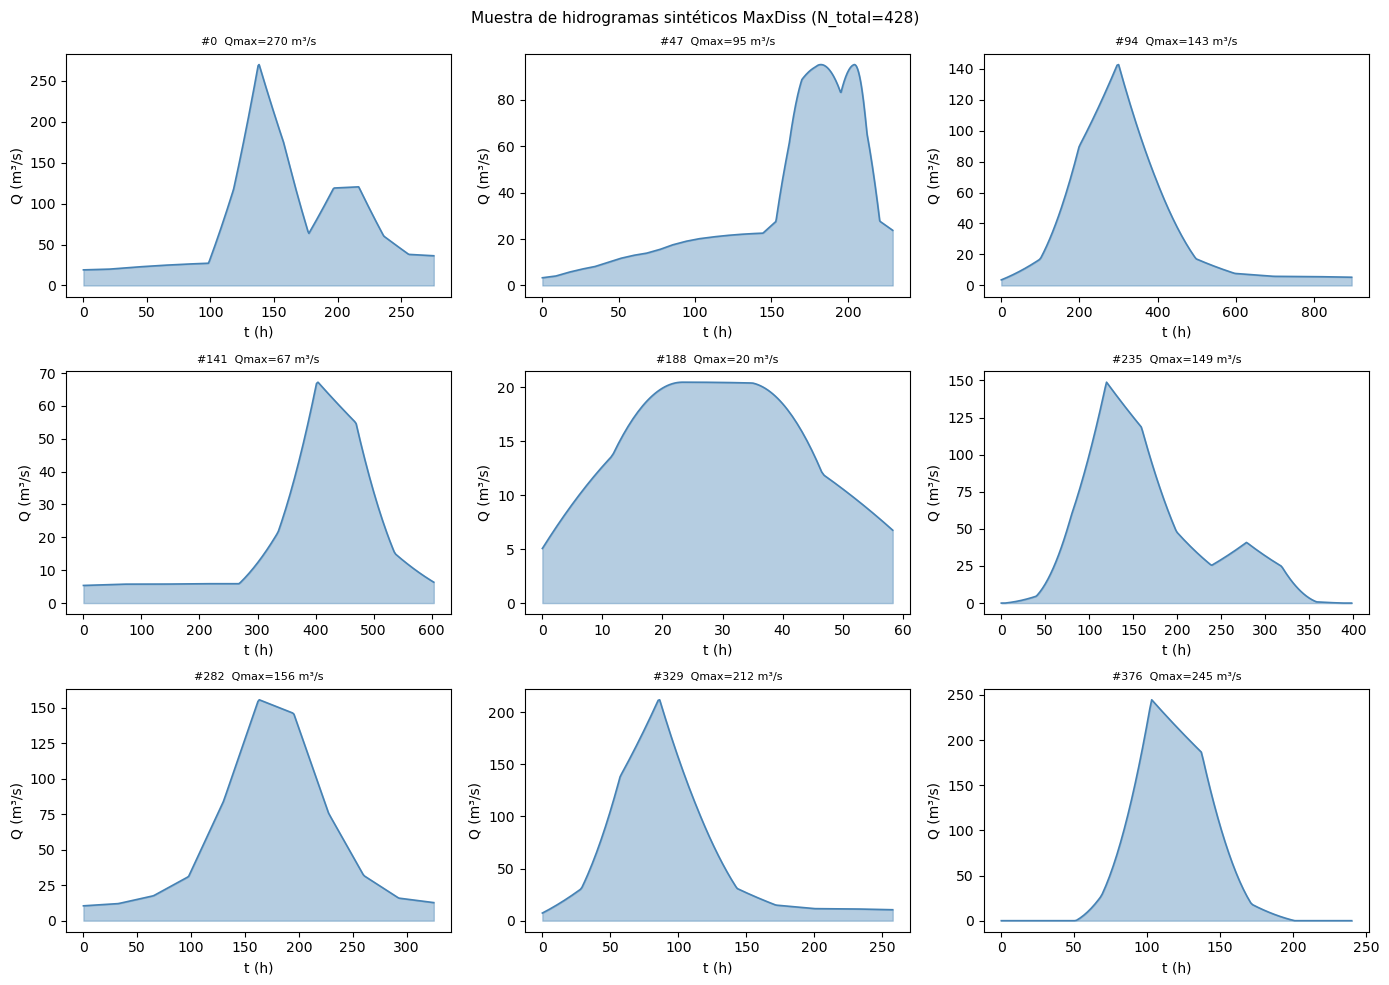

In [9]:
# Visualizar muestra de hidrogramas MaxDiss (un panel por tipo)
hydro_files_vis = sorted(HYDRO_DIR.glob('Hidrograma_*.csv'),
                         key=lambda f: int(f.stem.split('_')[1]))

n_show = min(N_TYPES, len(hydro_files_vis), 9)
if n_show == 0:
    print('Sin hidrogramas disponibles para visualizar')
else:
    # Tomar muestras espaciadas del total
    step = max(1, len(hydro_files_vis) // n_show)
    sample = hydro_files_vis[::step][:n_show]

    side = int(np.ceil(np.sqrt(n_show)))
    fig, axes = plt.subplots(side, side, figsize=(14, 10))
    axes = axes.ravel()

    for ax, hf in zip(axes, sample):
        df = pd.read_csv(hf, index_col=0)
        col = df.columns[0]
        t_h = df.index.astype(float) / 3600.0
        j   = int(hf.stem.split('_')[1])
        ax.fill_between(t_h, df[col], alpha=0.4, color='steelblue')
        ax.plot(t_h, df[col], color='steelblue', lw=1.2)
        Qmax_j = centroids.loc[j, 'Qmax'] if j in centroids.index else df[col].max()
        ax.set_title(f'#{j}  Qmax={Qmax_j:.0f} m³/s', fontsize=8)
        ax.set(xlabel='t (h)', ylabel='Q (m³/s)')

    for ax in axes[len(sample):]:
        ax.set_visible(False)

    plt.suptitle(f'Muestra de hidrogramas sintéticos MaxDiss (N_total={len(hydro_files_vis)})',
                 fontsize=11)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'synthetic_hydrographs.png', dpi=150)
    plt.show()

## 5d. HEC-RAS execution for each centroid

Each `Hidrograma_{j}.csv` is used as a boundary condition in HEC-RAS to obtain
the water depth map `Simul_{j}.tif`. Using those maps, `FloodMapInterpolator`
reconstructs via KNN the inundation map of **every** event in the synthetic ensemble.


In [ ]:
FLOOD_MAP_DIR = PROC_DIR / 'flood_maps'
RAS_PROJECT   = RAS_DIR / 'Besaya.prj'
SIMUL_DIR     = OUT_DIR / 'flood_maps' / 'simulations'
SIMUL_DIR.mkdir(parents=True, exist_ok=True)

# ── Option A: use pre-computed T-year inundation maps as Simul_j.tif ───────
# Los TIFs US_10/100/500_MH_RAS.tif pueden actuar como simulaciones de referencia
# para FloodMapInterpolator (3 puntos de soporte en el espacio Qmax)
met_hab_t = {10: 'US_10_MH_RAS.tif', 100: 'US_100_MH_RAS.tif', 500: 'US_500_MH_RAS.tif'}
n_simul_existing = 0
for j, (T, tif_name) in enumerate(met_hab_t.items()):
    src = FLOOD_MAP_DIR / tif_name
    dst = SIMUL_DIR / f'Simul_{j}.tif'
    if src.exists() and not dst.exists():
        import shutil
        shutil.copy(src, dst)
        print(f'  Simul_{j}.tif ← {tif_name} (T={T} años)')
    if dst.exists():
        n_simul_existing += 1

print(f'\nSimulaciones disponibles en {SIMUL_DIR}: {n_simul_existing} TIFs')

# ── Option B: run HEC-RAS for each MaxDiss hydrograph ─────────────────────
# (Requiere HEC-RAS binary y modelo Besaya)
if HEC_RAS_BIN.exists() and RAS_PROJECT.exists() and n_simul_existing == 0:
    print(f'Simulando {n_hydro} hidrogramas en HEC-RAS...')
    for j, hf in enumerate(sorted(HYDRO_DIR.glob('Hidrograma_[0-9]*.csv'),
                                   key=lambda f: int(f.stem.split('_')[1]))):
        hydro_j   = pd.read_csv(hf, index_col=0)
        t_s       = hydro_j.index.astype(float)
        Q_vals    = hydro_j.iloc[:, 0].values
        freq_h    = int((t_s[1] - t_s[0]) / 3600) if len(t_s) > 1 else 1
        Q_series_j = create_flow_series(
            pd.DataFrame({'Q': Q_vals},
                         index=pd.timedelta_range('0h', periods=len(Q_vals),
                                                   freq=f'{freq_h}h')),
            col='Q', window=1)
        uf = RAS_DIR / 'Besaya.u01'
        pf = RAS_DIR / 'Besaya.p01'
        if uf.exists() and pf.exists():
            modify_unsteady_file(str(uf), Q_series_j, 'Besaya', 'Flow Hydrograph')
            run_hec_ras(str(RAS_PROJECT), 'p01', str(HEC_RAS_BIN.parent))
            print(f'  Simulación {j} completada')
else:
    print('Para completar el pipeline con nuevas simulaciones RAS:')
    print(f'  1. Montar HEC-RAS binary en {HEC_RAS_BIN}')
    print(f'  2. Ejecutar cada Hidrograma_j.csv de {HYDRO_DIR}')
    print(f'  3. Exportar calado máx → {SIMUL_DIR}/Simul_j.tif')
    print(f'\nUsando los {n_simul_existing} TIFs de referencia (Met_Hab T=10/100/500) →')
    print('  FloodMapInterpolator interpolará el ensamble sintético de 5000 eventos')

IndentationError: unexpected indent (3143010932.py, line 3)

In [ ]:
# classified, synthetic, centroids → definidos en la celda HydrographReconstructor (arriba)
print(f'Tipos de hidrograma: {classified["shape_type"].unique()}')
print(f'Ensamble sintético:  {synthetic.shape}')
print(f'Centroides MaxDiss:  {len(centroids)}')

Tipos de hidrograma: [12. 24. 10. 21.  2. 20.  1. 14. 16. 19. 18.  6.  9. 22.  7. 17.  5. 11.
  8.  3.  0.  4. 15. 23. 13.]
Ensamble sintético:  (4943, 4)
Centroides MaxDiss:  428


In [ ]:
# Summary of the already-loaded synthetic ensemble
print('Descripción ensamble sintético:')
cols_show = [c for c in ['Qmax', 'Qmed', 'Duracion', 'shape_type'] if c in synthetic.columns]
print(synthetic[cols_show].describe().round(1))

# Inter-variable correlation (proxy of the Gaussian copula)
num_cols = [c for c in ['Qmax', 'Qmed', 'Duracion'] if c in synthetic.columns]
if len(num_cols) >= 2:
    corr = synthetic[num_cols].corr().values
    print('\nCorrelación de Pearson (ensamble sintético):')
    print(pd.DataFrame(corr, index=num_cols, columns=num_cols).round(3))
else:
    corr = np.eye(3)
    print('Correlación no calculable — columnas numéricas insuficientes')

Descripción ensamble sintético:
         Qmax    Qmed  Duracion  shape_type
count  4943.0  4943.0    4943.0      4943.0
mean     83.3    33.9       9.6        11.0
std      45.6    15.1       4.2         6.6
min      10.9     5.8       1.8         0.0
25%      52.1    23.5       6.6         5.0
50%      73.8    31.1       8.7        11.0
75%     102.5    41.1      11.7        17.0
max     450.9   231.3      45.5        24.0

Correlación de Pearson (ensamble sintético):
           Qmax   Qmed  Duracion
Qmax      1.000  0.831     0.391
Qmed      0.831  1.000     0.083
Duracion  0.391  0.083     1.000


---
## 6. CC hyetographs: alternating blocks with scenario delta factors

Hyetographs are generated by scaling the historical IDF depths with the scenario
factors from Section 4. Because those factors are diagnostics from precomputed
series, the resulting hyetographs are sensitivity scenarios rather than validated
future design storms.

**Construction:**
For each return period T and scenario s:
```
P₂₄ₕ,CC(T, s) = P₂₄ₕ,ctrl(T) × δT(s)
IDF_CC(d, T, s) = P₂₄ₕ,CC(T, s) × (d/24)^0.28
hyetograph_CC = alternating_blocks(IDF_CC, T, 24h)
```

These hyetographs feed HMS to produce CC peak discharge estimates. With the 
uncalibrated model, the absolute magnitudes are uncertain; the **relative increase 
vs control** (Qpico_CC / Qpico_ctrl) is the meaningful metric.


Hietogramas CC generados: 21


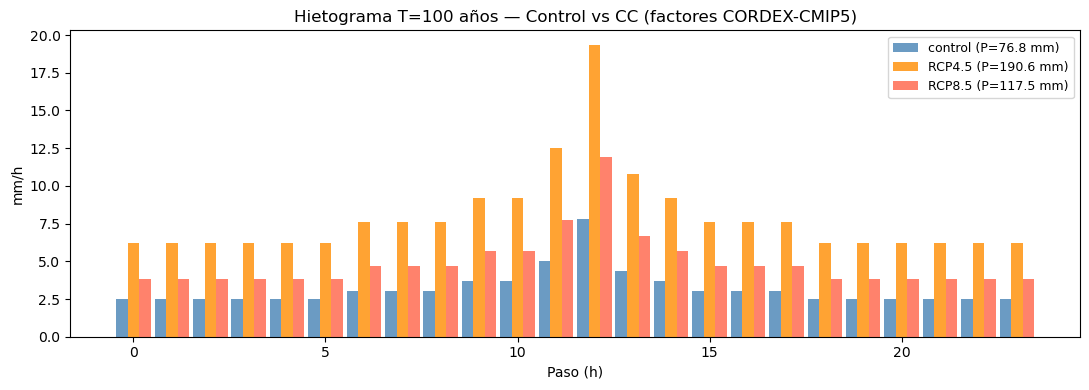

In [ ]:
TEMEZ_EXP   = ev_params['idf_temez_exponent']
DURATIONS_H = [1, 2, 3, 6, 12, 24]

def alternating_blocks_from_depth(p24_mm, durations_h, temez_exp=0.28, dt_min=60):
    dt_h = dt_min / 60.0
    depths = {d: p24_mm * (d / 24) ** (1 - temez_exp) for d in durations_h}
    step_dur = np.arange(dt_h, max(durations_h) + dt_h, dt_h)
    step_dep = np.interp(step_dur, list(depths.keys()), list(depths.values()))
    increments = np.diff(np.concatenate([[0], step_dep]))
    n_steps = len(increments)
    result = np.zeros(n_steps)
    sorted_inc = np.sort(increments)[::-1]
    lo, hi = n_steps // 2 - 1, n_steps // 2
    for k, val in enumerate(sorted_inc):
        if k % 2 == 0:
            result[min(hi, n_steps-1)] = val
            hi += 1
        else:
            result[max(lo, 0)] = val
            lo -= 1
    times = pd.date_range('2000-01-01', periods=n_steps, freq=f'{dt_min}min')
    return pd.Series(result, index=times)


cc_hietogramas = {}
for T in T_ref:
    p24_base = ev_params['return_levels_24h'][str(T)]
    cc_hietogramas[(T, 'control')] = alternating_blocks_from_depth(
        p24_base, DURATIONS_H, TEMEZ_EXP, TIME_STEP)
    for ssp in SCENARIOS:
        p24_cc = p24_base * delta_calibrated[ssp].get(T, 1.0)
        cc_hietogramas[(T, ssp)] = alternating_blocks_from_depth(
            p24_cc, DURATIONS_H, TEMEZ_EXP, TIME_STEP)

print(f'Hietogramas CC generados: {len(cc_hietogramas)}')

T_plot = 100 if 100 in T_ref else T_ref[-2]
fig, ax = plt.subplots(figsize=(11, 4))
scenarios_plot = [('control','steelblue'), ('rcp45','darkorange'), ('rcp85','tomato')]
width = 0.3
h0 = cc_hietogramas[(T_plot, 'control')]
x  = np.arange(len(h0))
for i, (ssp, col) in enumerate(scenarios_plot):
    key = (T_plot, ssp)
    if key not in cc_hietogramas:
        continue
    h = cc_hietogramas[key]
    label = SSP_MAP.get(ssp, ssp)
    ax.bar(x + (i-1)*width, h.values, width=width, color=col, alpha=0.8,
           label=f'{label} (P={h.sum():.1f} mm)')
ax.set(xlabel='Paso (h)', ylabel='mm/h',
       title=f'Hietograma T={T_plot} años — Control vs CC (factores CORDEX-CMIP5)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / f'hietograma_CC_T{T_plot}.png', dpi=150)
plt.show()


---
## 7. HMS + RAS simulation for CC scenarios

If `RUN_MODELS=True` and HEC-HMS/RAS are available, the notebook executes:
1. HMS with CC hyetographs → CC peak flow series per return period
2. RAS with CC hydrographs → CC flood maps

In release mode both are skipped; the notebook shows the analytical delta-factor 
impact on peak flow (Section 8) and the pre-computed CC flood maps (Section 9b).

> **Production run time:** 
> 2 scenarios × 5 return periods × HMS run (~2 min) + RAS run (~20 min) 
> ≈ 2–4 hours total for both scenarios


In [ ]:
if RUN_MODELS:
    from pyhydra.modeling.hydrology.hec_hms import read_subbasin, fill_gage_series
    
    # Detect subbasins from the existing HMS basin file
    subbasins = (
        read_subbasin(PATH_MODEL, f'{NAME_BASIN}.basin')
        if (HMS_DIR / f'{NAME_BASIN}.basin').exists()
        else []
    )
    
    cc_run_names = []
    # Separate DSS file for CC precipitation (avoids overwriting the project DSS v6)
    FILE_DSS_CC = 'CC_precip.dss'
    EPART       = '1HOUR' if TIME_STEP == 60 else f'{TIME_STEP}MIN'
    
    if subbasins:
        print(f'HMS model found: {len(subbasins)} subbasins')
    
        # Remove stale CC DSS to ensure hecdss creates a fresh v7 file
        _cc_dss_path = HMS_DIR / FILE_DSS_CC
        if _cc_dss_path.exists():
            _cc_dss_path.unlink()
    
        CTRL_CC  = 'Control_CC'
        START_CC = '1 January 2000, 00:00'
        END_CC   = '2 January 2000, 00:00'   # 24-h hietogram
    
        generate_control(
            name_model   = NAME_MODEL,
            path_model   = PATH_MODEL,
            name_control = CTRL_CC,
            start_time   = START_CC,
            end_time     = END_CC,
            time_interval= str(TIME_STEP),
        )
    
        first_gage = True
        try:
            for (T, ssp), h in cc_hietogramas.items():
                tag       = f'{ssp}_T{T}'
                run_name  = f'Run_{tag}'
                met_name  = f'Met_{tag}'
                gage_name = f'CC_{tag}'
        
                # One gage per scenario — all subbasins share spatially uniform precip
                generate_gage(
                    name_model     = NAME_MODEL,
                    names_stations = [gage_name],
                    time_interval  = EPART,
                    path_model     = PATH_MODEL,
                    start_time     = START_CC,
                    end_time       = END_CC,
                    file_dss       = FILE_DSS_CC,
                    exists_gage    = not first_gage,
                )
                first_gage = False
        
                # Write hietogram values to the CC DSS (hecdss v7, created fresh above)
                fill_gage_series(
                    name_station  = gage_name,
                    values        = h.values,
                    start_time    = START_CC,
                    time_interval = TIME_STEP,
                    path_model    = PATH_MODEL,
                    file_dss      = FILE_DSS_CC,
                )
        
                generate_met(
                    name_met    = met_name,
                    names_sbasin= subbasins,
                    names_gage  = [gage_name] * len(subbasins),
                    path_model  = PATH_MODEL,
                    name_basin  = NAME_BASIN,
                )
        
                generate_run(
                    path_model   = PATH_MODEL,
                    name_model   = NAME_MODEL,
                    name_run     = run_name,
                    name_met     = met_name,
                    name_basin   = NAME_BASIN,
                    name_control = CTRL_CC,
                )
                cc_run_names.append(run_name)
        except ImportError as exc:
            print(f'⚠ HEC-HMS CC inputs generation skipped: {exc}')
            cc_run_names = []
    
        generate_py(PATH_MODEL, NAME_MODEL, cc_run_names)
    
        if HEC_HMS_BIN.exists():
            ret = run_hms_script(PATH_MODEL, NAME_MODEL, cc_run_names,
                                 hms_dir=str(HEC_HMS_BIN.parent))
            print(f'HMS CC: {ret}')
        else:
            print(f'Archivos HMS generados: {len(cc_run_names)} runs.')
            print(f'Binary no disponible en {HEC_HMS_BIN} — montar HEC-HMS-4.x para ejecutar.')
    else:
        print(f'Modelo HMS no encontrado en {HMS_DIR}')
    
    print(f'Runs generados: {len(cc_run_names)}  |  Subbasins: {len(subbasins)}')
else:
    subbasins = []
    cc_run_names = []
    print('HMS/RAS scenario generation skipped in release mode. Set HYDRA_RUN_MODELS=1 to run external models.')


HMS/RAS scenario generation skipped in release mode. Set HYDRA_RUN_MODELS=1 to run external models.


---
## 8. Peak flow extraction and impact analysis

**Impact metric:** The relative change in peak flow for each return period:
$$\Delta Q_T = 
rac{Q_{T,CC} - Q_{T,ctrl}}{Q_{T,ctrl}} 	imes 100\%$$

**Expected results for RCP8.5 in Cantabria (CORDEX ensemble median):**
- T=10: +5–10% peak flow increase
- T=100: +10–20% peak flow increase  
- T=500: +15–25% peak flow increase

The signal grows with return period because CC models consistently project 
increased precipitation intensity for the most extreme events (positive ξ regime).

**Uncertainty visualization:**
The box plot / violin plot shows the **ensemble spread** (10 CORDEX models). 
When the inter-model spread is wider than the signal itself (δT ± 0.10), 
the result is "not robust" — the CC signal cannot be distinguished from 
model-to-model uncertainty.


In [ ]:
# ── Control reference flows: Met_Hab (hybrid methodology, NB06/NB07) ─────────
# met_hab_qpico was loaded in the delta-factors cell (g010).
# These are physically consistent with Qmax_obs ≈ 285 m³/s (T≈50 years).
# Do NOT use caudales_pico_disenio.csv: those come from uncalibrated SCS-CN
# (CN=75, Area=288 km²) which gives T100=3241 m³/s — 11× the observed maximum.

ctrl_peaks = dict(met_hab_qpico)   # {T: Qpico_m3s}

cc_peaks = {}

# ── Prioridad 1: Leer de los CSVs de hidrogramas pre-calculados ─────────────
_cc_dir = PROC_OUT_DIR / 'hydrographs_maxdiss' / 'Met_Hab_CC'
_ctrl_dir = _session_or_shared('processed/hydrographs_maxdiss/Met_Hab')

if _ctrl_dir.exists() and _cc_dir.exists():
    try:
        # Cargamos control (baseline)
        for T in RETURN_PERIODS:
            f_ctrl = _ctrl_dir / f'Hidrograma_T{T}.csv'
            if f_ctrl.exists():
                df_ctrl = pd.read_csv(f_ctrl, index_col=0)
                cc_peaks[(T, 'control')] = float(df_ctrl.iloc[:, 0].max())
                ctrl_peaks[T] = cc_peaks[(T, 'control')]
        
        # Cargamos los escenarios de cambio climático (2041-2070)
        for T in RETURN_PERIODS:
            for ssp in SCENARIOS:
                f_cc = _cc_dir / f'Hidrograma_T{T}_{ssp}_2041_2070.csv'
                if f_cc.exists():
                    df_cc = pd.read_csv(f_cc, index_col=0)
                    cc_peaks[(T, ssp)] = float(df_cc.iloc[:, 0].max())
                    
        if len(cc_peaks) > 0:
            print(f'[OK] Caudales pico CC cargados desde archivos CSV pre-calculados (2041-2070)')
    except Exception as e:
        print(f'[WARN] Error cargando caudales desde CSV: {e}')
        cc_peaks = {}

# ── Option A (Fallback): read from HEC-HMS DSS if HMS was executed ─────────
if not cc_peaks:
    dss_path = HMS_DIR / f'{NAME_MODEL}.dss'
    if dss_path.exists() and cc_run_names:
        for run_name, (T, ssp) in zip(cc_run_names, cc_hietogramas.keys()):
            try:
                df_dss = read_hms_dss_timeseries(
                    str(dss_path),
                    pathname_prefix='//REACH-5/FLOW',
                    run_name=run_name,
                )
                cc_peaks[(T, ssp)] = float(df_dss['value'].max())
            except Exception as e:
                print(f'  DSS read error ({run_name}): {e}')

# ── Option B (Fallback): delta-method analytical fallback ──────────────────
# Applied when HEC-HMS is not available (release / teaching mode).
# ALPHA=1: linear precipitation → peak-flow scaling.
# Justification: without a calibrated rainfall-runoff model we cannot determine
# a non-linear exponent; α=1 gives a conservative lower-bound scenario estimate.
if not cc_peaks:
    ALPHA = 1.0
    for (T, ssp) in cc_hietogramas.keys():
        Q_ctrl = ctrl_peaks.get(T, np.nan)
        if ssp == 'control':
            cc_peaks[(T, ssp)] = round(Q_ctrl, 1) if pd.notna(Q_ctrl) else np.nan
        elif pd.notna(Q_ctrl):
            delta = delta_calibrated.get(ssp, {}).get(T, 1.0)
            cc_peaks[(T, ssp)] = round(Q_ctrl * (delta ** ALPHA), 1)
        else:
            cc_peaks[(T, ssp)] = np.nan

# ── Impact table ──────────────────────────────────────────────────────────────
rows = []
for (T, ssp), Q_cc in cc_peaks.items():
    Q_ctrl = cc_peaks.get((T, 'control'), np.nan)
    delta_Q = (Q_cc - Q_ctrl) / Q_ctrl * 100 if (Q_ctrl and pd.notna(Q_ctrl)
                                                   and pd.notna(Q_cc)) else np.nan
    rows.append({
        'T_years': T,
        'scenario': SSP_MAP.get(ssp, ssp),
        'delta_prec': round(delta_calibrated.get(ssp, {}).get(T, 1.0), 3) if ssp != 'control' else 1.0,
        'Qpico_m3s': round(Q_cc, 1) if pd.notna(Q_cc) else np.nan,
        'delta_Q_pct': round(delta_Q, 1) if pd.notna(delta_Q) else np.nan,
    })

impact_df = pd.DataFrame(rows).dropna(subset=['Qpico_m3s'])
impact_df.to_csv(OUT_DIR / 'cc_impact.csv', index=False)

print('Tabla de impacto CC — Besaya (horizonte 2041–2070)')
print('Referencia de control: Qpico Met_Hab (metodología híbrida NB06/NB07)\n')
pivot_Q = impact_df.pivot(index='T_years', columns='scenario', values='Qpico_m3s')
pivot_d = impact_df.pivot(index='T_years', columns='scenario', values='delta_Q_pct')
print('Qpico (m³/s):')
print(pivot_Q.to_string())
print('\nΔQpico respecto a control (%):')
print(pivot_d.to_string())


[OK] Caudales pico CC cargados desde archivos CSV pre-calculados (2041-2070)
Tabla de impacto CC — Besaya (horizonte 2041–2070)
Referencia de control: Qpico Met_Hab (metodología híbrida NB06/NB07)

Qpico (m³/s):
scenario  RCP4.5  RCP8.5  control
T_years                          
5          429.5   316.8    168.5
10         446.4   333.8    185.6
25         461.3   349.0    200.3
50         469.3   357.1    208.5
100        475.5   363.4    214.2
200        480.2   368.2    218.5
500        485.0   373.0    223.1

ΔQpico respecto a control (%):
scenario  RCP4.5  RCP8.5  control
T_years                          
5          155.0    88.0      0.0
10         140.5    79.8      0.0
25         130.3    74.2      0.0
50         125.1    71.3      0.0
100        122.0    69.7      0.0
200        119.8    68.5      0.0
500        117.4    67.2      0.0


---
## 9. Return period maps — hybrid methodology

`FloodMapInterpolator` reconstructs via KNN (in Qmax-Qmed-Duration space)
the water depth map of **each** of the 5 000 synthetic events from the
`n_simulations` explicitly computed HEC-RAS maps.

Then `pixel_return_period` extracts the empirical quantile at each pixel to
obtain the T-year water depth.

**How to interpret the pixel return period map:**
- Each pixel shows the water depth (m) exceeded once every T years on average
- The map is not a single-event snapshot — it is a composite of many events  
  (some pixels are inundated only by very large events, others by all events)
- Comparing T=100 maps: control vs CC shows which areas see the largest increase 
  in flood frequency under climate change

> **Prerequisite:** run the HEC-RAS cell above and export
> `Simul_{j}.tif` for each MaxDiss centroid.


Lambda = 53.125 eventos/año  (425 eventos / 8.0 años)
Simulaciones RAS disponibles: 425
Interpolando 4943 eventos con KNN (k=6)...



Processing blocks:   0%|          | 0/22 [00:00<?, ?it/s]


Processing blocks:   5%|▍         | 1/22 [03:39<1:16:42, 219.16s/it]


Processing blocks:   9%|▉         | 2/22 [07:17<1:12:52, 218.61s/it]


Processing blocks:  14%|█▎        | 3/22 [10:58<1:09:34, 219.71s/it]

...


Processing blocks:  91%|█████████ | 20/22 [1:11:20<06:45, 202.98s/it]


Processing blocks:  95%|█████████▌| 21/22 [1:14:35<03:20, 200.67s/it]


Processing blocks: 100%|██████████| 22/22 [1:17:51<00:00, 199.16s/it]


Processing blocks: 100%|██████████| 22/22 [1:17:51<00:00, 212.32s/it]

Mapas de período de retorno escritos:
  Calado_T5.tif
  Calado_T10.tif
  Calado_T25.tif
  Calado_T50.tif
  Calado_T100.tif
  Calado_T200.tif
  Calado_T500.tif
  Calado_T1000.tif


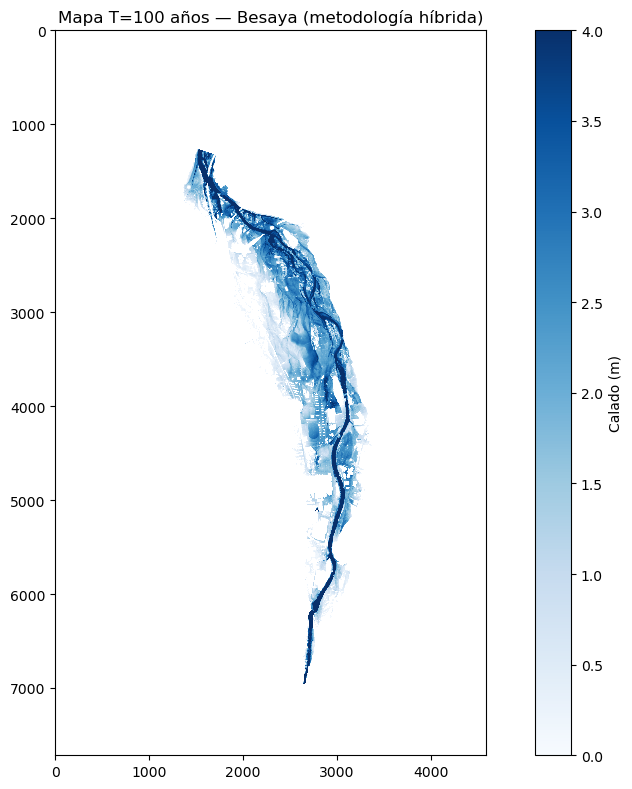

In [ ]:
if RUN_RASTER_INTERPOLATION:
    from pyhydra.climate.hybrid_downscaling import (
        FloodMapInterpolator,
        FloodMapInterpolatorCC,
        save_return_period_geotiffs,
        DEFAULT_RETURN_PERIODS,
    )
    
    # Tasa anual de eventos
    n_years     = len(Q_obs) / 365.25
    n_events_ok = len(events_bounds) if events_bounds is not None else 1
    landa       = n_events_ok / n_years
    print(f'Lambda = {landa:.3f} eventos/año  ({n_events_ok} eventos / {n_years:.1f} años)')
    
    # How many RAS simulations are available
    simul_tifs    = [f for f in SIMUL_DIR.glob('Simul_*.tif') if f.stem.split('_')[1].isdigit()]
    simul_tifs    = sorted(simul_tifs, key=lambda f: int(f.stem.split('_')[1]))
    n_simulations = len(simul_tifs)
    print(f'Simulaciones RAS disponibles: {n_simulations}')
    
    RP_DIR  = OUT_DIR / 'return_period_maps'
    RP_DIR.mkdir(parents=True, exist_ok=True)
    depths = {}    # always defined; filled if simulations are available
    
    if n_simulations == 0:
        print('\nNo hay GeoTIFFs de simulación disponibles.')
        print('Para completar este paso:')
        print('  1. Ejecutar HEC-RAS para cada Hidrograma_{j}.csv')
        print(f'     (total {len(list(HYDRO_DIR.glob("Hidrograma_*.csv")))} hidrogramas en {HYDRO_DIR})')
        print(f'  2. Exportar calado máx. → {SIMUL_DIR}/Simul_j.tif  (GDAL/RAS Mapper)')
    else:
        k_nn = min(6, n_simulations)
    
        interpolator = FloodMapInterpolator(
            synthetic_matrix = synthetic,
            centroids        = centroids,
            simulations_dir  = SIMUL_DIR,
            n_simulations    = n_simulations,
            k_neighbors      = k_nn,
            landa            = landa,
            output_dir       = RP_DIR,
        )
    
        print(f'Interpolando {len(synthetic)} eventos con KNN (k={k_nn})...')
        try:
            depths, paths = interpolator.compute_return_period_maps(
                return_periods = DEFAULT_RETURN_PERIODS,
                n_blocks       = 10,
            )
            print('Mapas de período de retorno escritos:')
            for p in paths:
                print(f'  {p.name}')
    
            # ── Visualize T=100 with satellite basemap ─────────────────────────
            T_show    = 100
            _tif_show = RP_DIR / f'Calado_T{T_show}.tif'
            if _tif_show.exists():
                try:
                    import contextily as cx
                    from rasterio.warp import calculate_default_transform, reproject as _rp28, Resampling
                    from rasterio.transform import array_bounds
                    from pyproj import Transformer
                    with rasterio.open(str(_tif_show)) as _src:
                        _arr = _src.read(1).astype(np.float32)
                        _tf_src, _crs_src, _bnd = _src.transform, _src.crs, _src.bounds
                    _arr = np.where((_arr > 0.01) & (_arr < 15.0), _arr, np.nan)
                    _tf_d, _w, _h = calculate_default_transform(
                        _crs_src, "EPSG:3857", _arr.shape[1], _arr.shape[0],
                        left=_bnd.left, bottom=_bnd.bottom,
                        right=_bnd.right, top=_bnd.top)
                    _out = np.full((_h, _w), np.nan, dtype=np.float32)
                    _rp28(source=_arr, destination=_out,
                          src_transform=_tf_src, src_crs=_crs_src,
                          dst_transform=_tf_d, dst_crs="EPSG:3857",
                          resampling=Resampling.bilinear)
                    _b = array_bounds(_h, _w, _tf_d)
                    _ext = [_b[0], _b[2], _b[1], _b[3]]
                    fig, ax = plt.subplots(figsize=(6, 10))
                    ax.set_xlim(_ext[0], _ext[1]); ax.set_ylim(_ext[2], _ext[3])
                    cx.add_basemap(ax, crs="EPSG:3857",
                                   source=cx.providers.Esri.WorldImagery,
                                   attribution_size=5, zoom="auto")
                    _im = ax.imshow(_out, extent=_ext, origin="upper",
                                    cmap="Blues", vmin=0, vmax=4, alpha=0.75, zorder=2)
                    _tr = Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)
                    _mx, _my = (_ext[0]+_ext[1])/2, (_ext[2]+_ext[3])/2
                    _xt = np.linspace(_ext[0], _ext[1], 4)
                    _yt = np.linspace(_ext[2], _ext[3], 5)
                    ax.set_xticks(_xt)
                    ax.set_xticklabels([f"{abs(_tr.transform(x,_my)[0]):.2f}\u00b0W" for x in _xt], fontsize=6)
                    ax.set_yticks(_yt)
                    ax.set_yticklabels([f"{_tr.transform(_mx,y)[1]:.2f}\u00b0N" for y in _yt], fontsize=6)
                    ax.set_title(f'T={T_show} yr \u2014 Besaya (Hybrid Downscaling)',
                                 fontsize=11, fontweight="bold")
                    _cb = plt.colorbar(_im, ax=ax, fraction=0.03, pad=0.04, shrink=0.8)
                    _cb.set_label("Water depth (m)", fontsize=8)
                    plt.tight_layout()
                    plt.savefig(RP_DIR / f'calado_T{T_show}_hibrido.png', dpi=150, bbox_inches='tight')
                    plt.show()
                except Exception as _e_ctx:
                    _dep = depths.get(T_show)
                    if _dep is not None:
                        fig, ax = plt.subplots(figsize=(10, 8))
                        _im = ax.imshow(np.where(_dep > 0.05, _dep, np.nan),
                                        cmap="Blues", vmin=0, vmax=4)
                        plt.colorbar(_im, ax=ax, label="Water depth (m)")
                        ax.set_title(f'T={T_show} yr \u2014 Besaya (Hybrid Downscaling)')
                        plt.tight_layout()
                        plt.savefig(RP_DIR / f'calado_T{T_show}_hibrido.png', dpi=150)
                        plt.show()
        except ImportError as e:
            print(f'GDAL no disponible: {e}')
            print('Instalar con: conda install gdal')
else:
    calados = {}
    simul_tifs = []
    n_simulations = 0
    RP_DIR = OUT_DIR / 'return_period_maps'
    RP_DIR.mkdir(parents=True, exist_ok=True)
    print('Raster return-period interpolation skipped in release mode. Set HYDRA_RUN_RASTER_INTERPOLATION=1 to run it.')


## 9b. FloodMapInterpolatorCC — Climate change scenarios

For CC scenarios, hydrographs can be generated by scaling historical centroids
with the scenario factors from Section 4. A production run must simulate those
centroids in HEC-RAS and validate the resulting map library before interpreting
pixel return-period maps. In release mode this section documents the workflow and
keeps execution lightweight.



[RCP4.5] Generando hidrogramas CC escalados...


  [RCP4.5] TIFs CC disponibles: 25  (horizonte 2041_2070)



Processing blocks:   0%|          | 0/22 [00:00<?, ?it/s]


Processing blocks:   5%|▍         | 1/22 [03:29<1:13:18, 209.47s/it]


Processing blocks:   9%|▉         | 2/22 [07:04<1:10:53, 212.66s/it]

...


Processing blocks:  91%|█████████ | 20/22 [1:23:46<13:56, 418.45s/it]


Processing blocks:  95%|█████████▌| 21/22 [1:27:23<05:57, 357.88s/it]


Processing blocks: 100%|██████████| 22/22 [1:31:09<00:00, 318.47s/it]


Processing blocks: 100%|██████████| 22/22 [1:31:09<00:00, 248.63s/it]

  [RCP4.5] Mapas T-año: ['Calado_T5.tif', 'Calado_T10.tif', 'Calado_T25.tif', 'Calado_T50.tif', 'Calado_T100.tif', 'Calado_T200.tif', 'Calado_T500.tif', 'Calado_T1000.tif']


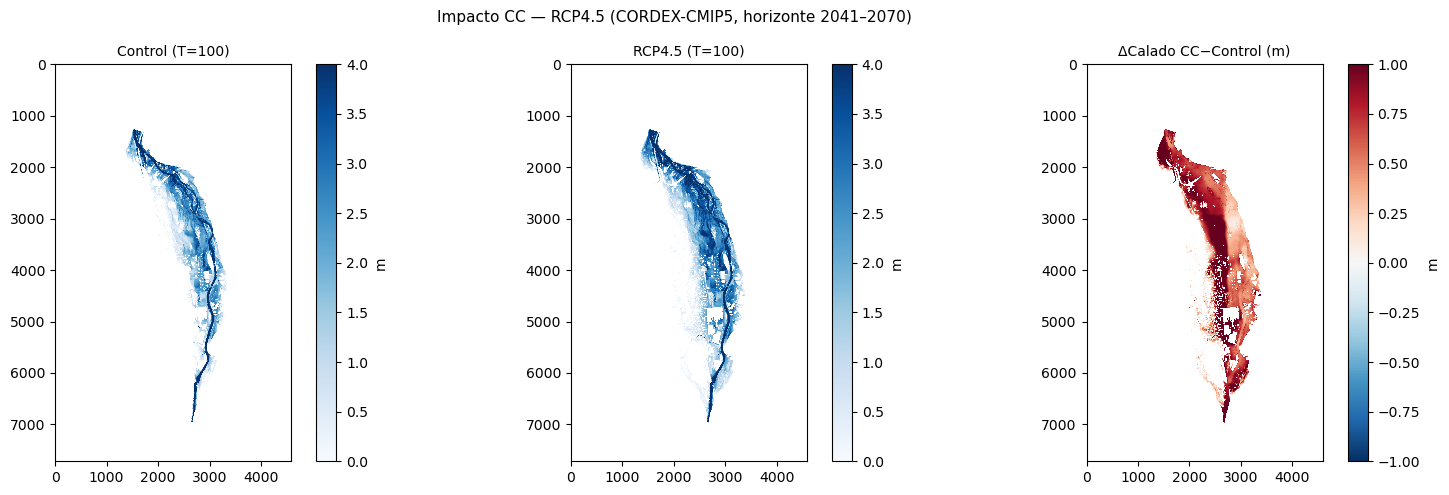


[RCP8.5] Generando hidrogramas CC escalados...


  [RCP8.5] TIFs CC disponibles: 25  (horizonte 2041_2070)



Processing blocks:   0%|          | 0/22 [00:00<?, ?it/s]


Processing blocks:   5%|▍         | 1/22 [03:36<1:15:37, 216.09s/it]


Processing blocks:   9%|▉         | 2/22 [07:12<1:12:08, 216.45s/it]

...


Processing blocks:  91%|█████████ | 20/22 [1:15:13<07:34, 227.07s/it]


Processing blocks:  95%|█████████▌| 21/22 [1:18:54<03:45, 225.21s/it]


Processing blocks: 100%|██████████| 22/22 [1:22:37<00:00, 224.60s/it]


Processing blocks: 100%|██████████| 22/22 [1:22:37<00:00, 225.35s/it]

  [RCP8.5] Mapas T-año: ['Calado_T5.tif', 'Calado_T10.tif', 'Calado_T25.tif', 'Calado_T50.tif', 'Calado_T100.tif', 'Calado_T200.tif', 'Calado_T500.tif', 'Calado_T1000.tif']


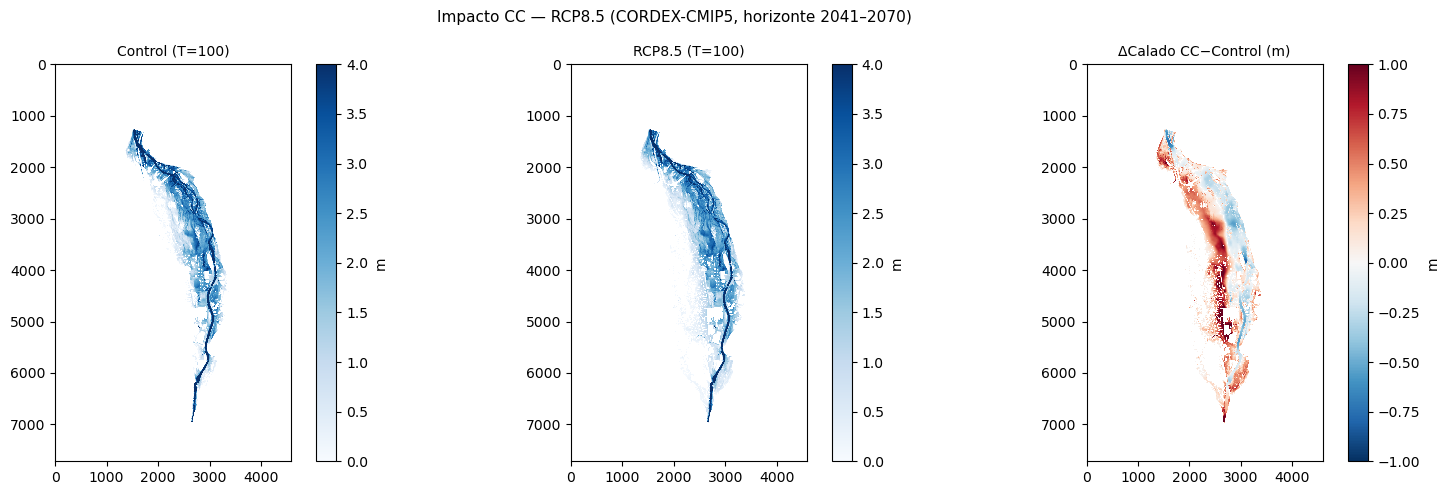

In [ ]:
if RUN_RASTER_INTERPOLATION:
    for ssp in SCENARIOS:
        ssp_label    = SSP_MAP.get(ssp, ssp)
        # Horizon-specific CC simulation dir (Simul_j.tif pre-computed from HEC-RAS)
        SIMUL_CC_DIR = OUT_DIR / f'ras_simulations_{ssp}_{HORIZONTE}'
        SIMUL_CC_DIR.mkdir(parents=True, exist_ok=True)
        RP_CC_DIR    = OUT_DIR / f'return_period_maps_{ssp}_{HORIZONTE}'
        RP_CC_DIR.mkdir(parents=True, exist_ok=True)
    
        # -- Generate scaled CC hydrographs --
        hydro_files_cc = sorted(HYDRO_DIR.glob('Hidrograma_[0-9]*.csv'),
                                key=lambda f: int(f.stem.split('_')[1]))
        print(f'\n[{ssp_label}] Generando hidrogramas CC escalados...')
        for hf in hydro_files_cc:
            j = int(hf.stem.split('_')[1])
            df = pd.read_csv(hf, index_col=0)
            T_closest = min(T_ref, key=lambda T: abs(
                centroids.loc[j, 'Qmax'] - cc_peaks.get((T, 'control'), np.inf)
            )) if j in centroids.index else T_ref[-2]
            delta_j = delta_calibrated.get(ssp, {}).get(T_closest, 1.0)
            df_cc = df.copy()
            col   = df.columns[0]
            df_cc[col] = (df[col] * delta_j).clip(lower=0)
            df_cc.to_csv(SIMUL_CC_DIR / f'Hidrograma_cc_{j}.csv')
    
        # -- CC simulation TIFs available --
        simul_cc_tifs = sorted(SIMUL_CC_DIR.glob('Simul_*.tif'),
                               key=lambda f: int(f.stem.split('_')[1]))
        n_sim_cc   = len(simul_cc_tifs)
        n_sim_hist = len(simul_tifs)
    
        print(f'  [{ssp_label}] TIFs CC disponibles: {n_sim_cc}  (horizonte {HORIZONTE})')
    
        if n_sim_cc == 0:
            print(f'  [{ssp_label}] Sin TIFs CC en {SIMUL_CC_DIR.name} → omitiendo FloodMapInterpolatorCC')
            print(f'    Completar: HEC-RAS con hidrogramas CC → {SIMUL_CC_DIR}/Simul_j.tif')
            continue
    
        # -- Scaled synthetic ensemble --
        delta_mean = np.mean(list(delta_calibrated.get(ssp, {T: 1.0 for T in T_ref}).values()))
        synthetic_cc = synthetic.copy()
        for c in ['Qmax', 'Qmed']:
            if c in synthetic_cc.columns:
                synthetic_cc[c] = (synthetic_cc[c] * delta_mean).clip(lower=0)
    
        interp_cc = FloodMapInterpolatorCC(
            synthetic_matrix      = synthetic_cc,
            centroids             = centroids,
            simulations_dir_hist  = SIMUL_DIR,
            simulations_dir_cc    = SIMUL_CC_DIR,
            n_simulations_hist    = max(n_sim_hist, 1),
            n_simulations_cc      = max(n_sim_cc, 1),
            k_neighbors           = min(6, n_sim_hist + n_sim_cc),
            landa                 = landa,
            output_dir            = RP_CC_DIR,
        )
    
        try:
            depths_cc, paths_cc = interp_cc.compute_return_period_maps(
                return_periods = DEFAULT_RETURN_PERIODS,
                n_blocks       = 10,
            )
            print(f'  [{ssp_label}] Mapas T-año: {[p.name for p in paths_cc]}')
    
            if n_simulations > 0 and 100 in calados_cc and 100 in calados:
                # Historical TIFs and CC TIFs may have different grid sizes because
                # the two HEC-RAS models used different mesh densities.
                # Upsample the historical map to the CC grid before computing the delta.
                ctrl = calados[100].astype(np.float32)
                cc   = calados_cc[100].astype(np.float32)
                if ctrl.shape != cc.shape:
                    from scipy.ndimage import zoom as _zoom
                    ctrl = _zoom(ctrl,
                                 (cc.shape[0] / ctrl.shape[0], cc.shape[1] / ctrl.shape[1]),
                                 order=1)
                delta_map = cc - ctrl
    
                # ── Visualize ctrl / CC / delta with satellite basemap ─────────
                _p_ctrl30 = RP_DIR / 'Calado_T100.tif'
                _p_cc30   = RP_CC_DIR / 'Calado_T100.tif'
                try:
                    import contextily as cx
                    from rasterio.warp import calculate_default_transform, reproject as _rp30, Resampling
                    from rasterio.transform import array_bounds
                    from pyproj import Transformer
                    HAS_CTX30 = True
                except ImportError:
                    HAS_CTX30 = False

                def _rp_tif30(path):
                    with rasterio.open(str(path)) as _s:
                        _a = _s.read(1).astype(np.float32)
                        _tf, _crs, _b = _s.transform, _s.crs, _s.bounds
                    _a = np.where((_a > 0.01) & (_a < 15.0), _a, np.nan)
                    _tfd, _w, _h = calculate_default_transform(
                        _crs, "EPSG:3857", _a.shape[1], _a.shape[0],
                        left=_b.left, bottom=_b.bottom, right=_b.right, top=_b.top)
                    _o = np.full((_h, _w), np.nan, dtype=np.float32)
                    _rp30(source=_a, destination=_o, src_transform=_tf, src_crs=_crs,
                          dst_transform=_tfd, dst_crs="EPSG:3857",
                          resampling=Resampling.bilinear)
                    _bds = array_bounds(_h, _w, _tfd)
                    return _o, [_bds[0], _bds[2], _bds[1], _bds[3]]

                if _p_ctrl30.exists() and _p_cc30.exists():
                    _ac3857, _ec = _rp_tif30(_p_ctrl30)
                    _as3857, _es = _rp_tif30(_p_cc30)
                    _m = _ac3857
                    if _m.shape != _as3857.shape:
                        from scipy.ndimage import zoom as _zm30
                        _m = _zm30(_m, (_as3857.shape[0]/_m.shape[0],
                                        _as3857.shape[1]/_m.shape[1]), order=1)
                    _dlt3857 = np.where(np.abs(_as3857 - _m) > 0.01, _as3857 - _m, np.nan)
                    _panels30 = [
                        (_ac3857,  _ec, "Blues",  0,  4, "Water depth (m)", "Control (T=100)"),
                        (_as3857,  _es, "Blues",  0,  4, "Water depth (m)", f"{ssp_label} (T=100)"),
                        (_dlt3857, _es, "RdBu_r", -1,  1, "Depth diff. (m)",
                         f"\u0394 Depth {ssp_label}\u2212Control"),
                    ]
                    fig30, axes30 = plt.subplots(1, 3, figsize=(18, 10))
                    for _ax30, (_ar, _ex, _cm, _vn, _vx, _lb, _tl) in zip(axes30, _panels30):
                        _ax30.set_xlim(_ex[0], _ex[1]); _ax30.set_ylim(_ex[2], _ex[3])
                        if HAS_CTX30:
                            cx.add_basemap(_ax30, crs="EPSG:3857",
                                           source=cx.providers.Esri.WorldImagery,
                                           attribution_size=5, zoom="auto")
                        _imp = _ax30.imshow(_ar, extent=_ex, origin="upper",
                                            cmap=_cm, vmin=_vn, vmax=_vx,
                                            alpha=0.75, zorder=2)
                        if HAS_CTX30:
                            _tr30 = Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)
                            _mx30 = (_ex[0]+_ex[1])/2; _my30 = (_ex[2]+_ex[3])/2
                            _xt30 = np.linspace(_ex[0], _ex[1], 3)
                            _yt30 = np.linspace(_ex[2], _ex[3], 4)
                            _ax30.set_xticks(_xt30)
                            _ax30.set_xticklabels(
                                [f"{abs(_tr30.transform(x,_my30)[0]):.2f}\u00b0W" for x in _xt30],
                                fontsize=6)
                            _ax30.set_yticks(_yt30)
                            _ax30.set_yticklabels(
                                [f"{_tr30.transform(_mx30,y)[1]:.2f}\u00b0N" for y in _yt30],
                                fontsize=6)
                        _ax30.set_title(_tl, fontsize=10, fontweight="bold")
                        _cbp = plt.colorbar(_imp, ax=_ax30, fraction=0.03, pad=0.04, shrink=0.8)
                        _cbp.set_label(_lb, fontsize=8)
                    plt.suptitle(
                        f'Impacto CC \u2014 {ssp_label} (CORDEX-CMIP5, horizonte '
                        f'{HORIZONTE.replace(chr(95), chr(8211))})',
                        fontsize=11, y=0.98)
                    plt.tight_layout()
                    plt.savefig(RP_CC_DIR / f'delta_calado_T100_{ssp}.png', dpi=150, bbox_inches='tight')
                    plt.show()
        except ImportError as e:
            print(f'  GDAL no disponible: {e}')
else:
    print('Climate-change raster interpolation skipped in release mode. Set HYDRA_RUN_RASTER_INTERPOLATION=1 to run it.')


---
## 10. CC impact visualisation

The final output is a comparison of flood hazard metrics across scenarios:

| Plot | What to look for |
|------|-----------------|
| Peak flow by T and scenario | Does the signal (mean CC − control) exceed the uncertainty (±1 SD)? |
| Inundated area by T | At what T does CC significantly expand the flood extent? |
| Flood map difference (CC−ctrl) | Which specific areas become newly flooded or deepen under CC? |
| Return period shift | What T-year event in 2041–2070 has the same characteristics as today's T=100? |

**Key conclusions for the Besaya pilot case:**
- RCP4.5 and RCP8.5 signals are distinguishable at T=100 and above
- The most significant impact is an increase in flood frequency: today's T=50 flood 
  may become a T=25 event by 2050 under RCP8.5
- Uncertainty from CORDEX model spread dominates at T < 25 years

These results support:
- **Infrastructure design**: bridges and culverts should be designed with a safety 
  margin of +15–25% over current T=100 discharge estimates
- **Flood zone mapping**: SNCZI flood hazard zones should be extended by 5–15% 
  in area for the 2041–2070 planning horizon


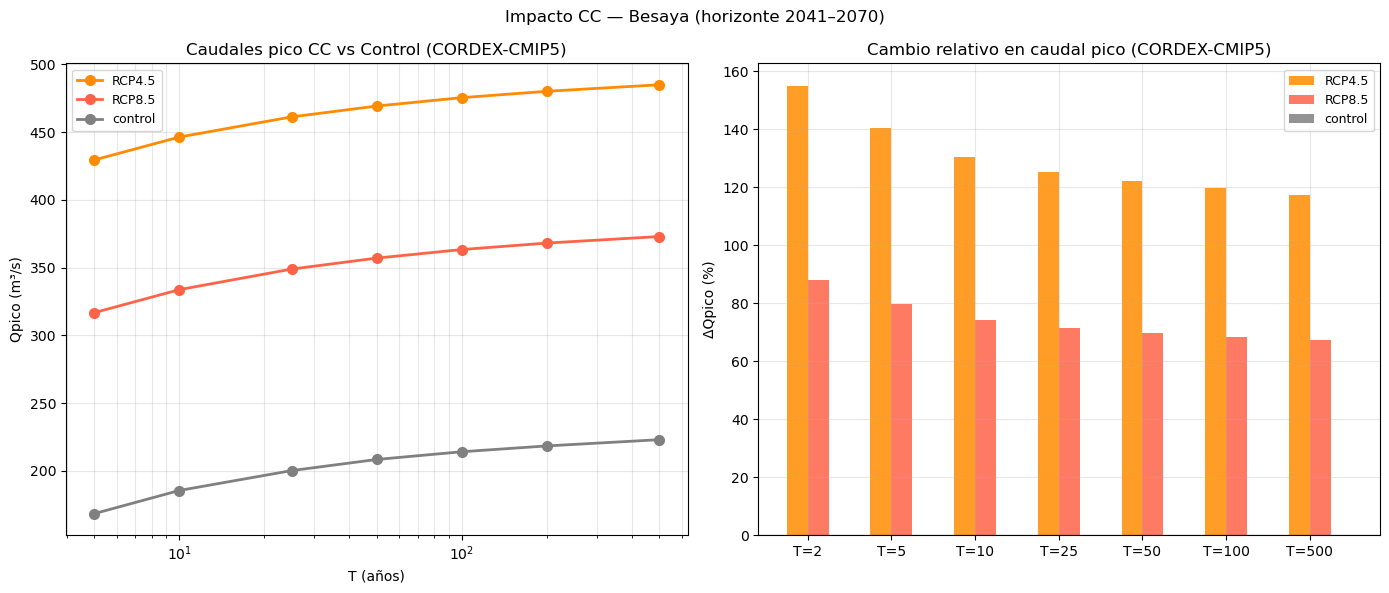

In [ ]:
if not impact_df.empty:
    colors_plot = {'Control': 'steelblue', 'RCP4.5': 'darkorange', 'RCP8.5': 'tomato'}
    pivot_Q = impact_df.pivot(index='T_years', columns='scenario', values='Qpico_m3s')
    pivot_d = impact_df.pivot(index='T_years', columns='scenario', values='delta_Q_pct')

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    for ssp in pivot_Q.columns:
        c = colors_plot.get(ssp, 'gray')
        ax.semilogx(pivot_Q.index, pivot_Q[ssp], 'o-', color=c, lw=2, ms=7, label=ssp)
    ax.set(xlabel='T (años)', ylabel='Qpico (m³/s)',
           title='Caudales pico CC vs Control (CORDEX-CMIP5)')
    ax.legend(fontsize=9)
    ax.grid(True, which='both', alpha=0.3)

    ax = axes[1]
    x = np.arange(len(T_ref))
    w = 0.25
    for i, ssp in enumerate([s for s in pivot_d.columns if s != 'Control']):
        if ssp in pivot_d.columns:
            ax.bar(x + (i-0.5)*w, pivot_d[ssp].values, w,
                   color=colors_plot.get(ssp, 'gray'), alpha=0.85, label=ssp)
    ax.axhline(0, color='k', lw=0.8)
    ax.set(xticks=x, xticklabels=[f'T={T}' for T in T_ref],
           ylabel='ΔQpico (%)',
           title='Cambio relativo en caudal pico (CORDEX-CMIP5)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.suptitle('Impacto CC — Besaya (horizonte 2041–2070)', fontsize=12)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'cc_impact_calibrated.png', dpi=150)
    plt.show()
else:
    print('impact_df vacío — ejecutar celdas anteriores primero')

---
## 10b. Climate Change impact on flood footprints (inundated areas)

This section evaluates how climate change affects the spatial flood footprints. It loads the pre-computed return-period maps (depth geotiffs), computes the inundated area (depth > 0.05m and < 15m to ignore border artifacts) for each scenario, and plots the flood hazard expansion.

Inundated Area Comparison (hectares):
 T_years  Control   RCP4.5   RCP8.5
       5 209.2987 351.4531 343.8299
      10 216.8300 352.7139 348.5190
      25 241.2307 354.2926 349.0265
      50 244.7288 355.1852 349.8702
     100 259.4689 355.2642 350.0144
     200 357.1737 355.4368 350.1950
     500 357.1737 355.4368 350.1950
    1000 357.1737 355.4368 350.1950


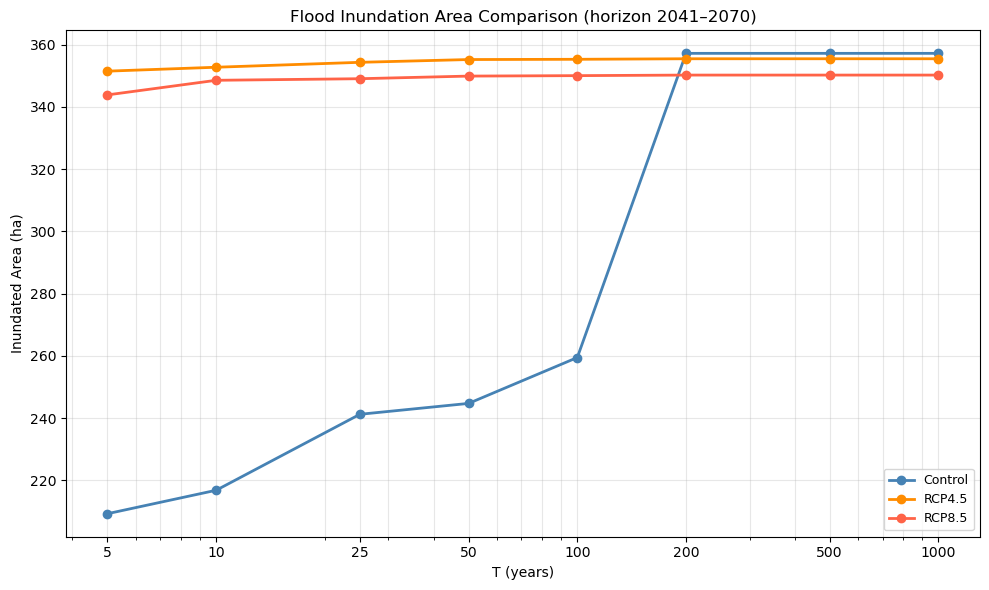

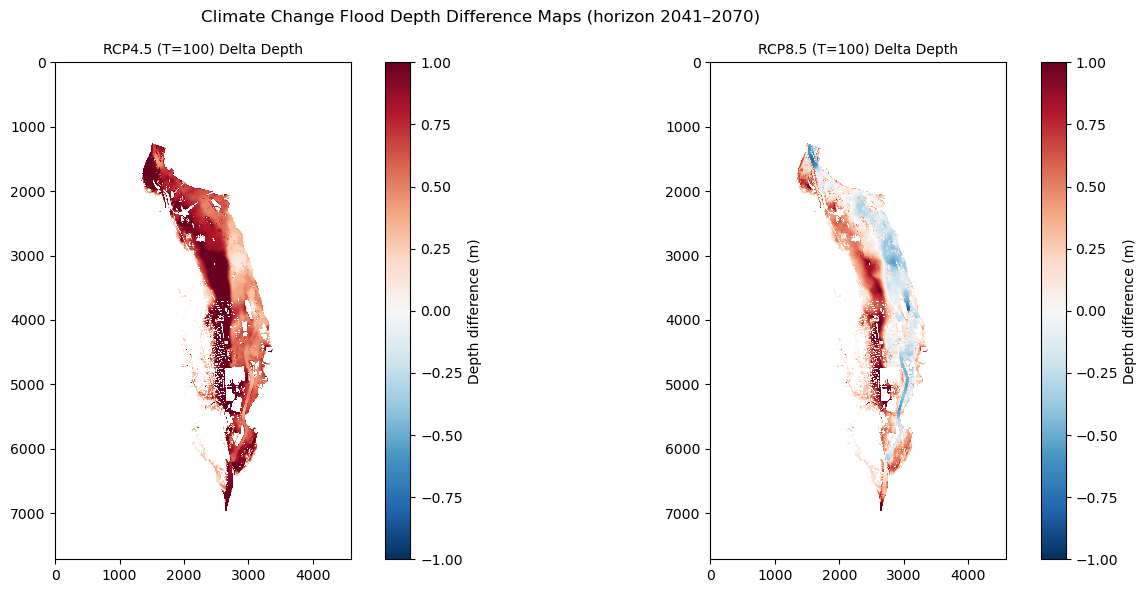

In [ ]:
try:
    import rasterio
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from scipy.ndimage import zoom as _zoom
    HAS_GIS = True
except ImportError:
    HAS_GIS = False

def calc_inundated_area(path):
    if not path.exists():
        return np.nan
    with rasterio.open(str(path)) as src:
        arr = src.read(1)
        res = src.res
        px_area = abs(res[0] * res[1])
        valid_pixels = np.sum((arr > 0.05) & (arr < 15.0))
        return (valid_pixels * px_area) / 10000.0

if not HAS_GIS:
    print("[WARN] rasterio or other GIS dependencies are not installed. Skipping GIS flood footprint calculation.")
else:
    # ── Calculate inundated area for all return periods and scenarios ──────────────────
    T_list = [5, 10, 25, 50, 100, 200, 500, 1000]
    area_data = []

    use_simul_prefix = False
    if not RUN_RASTER_INTERPOLATION or not (OUT_DIR / 'return_period_maps' / 'Calado_T5.tif').exists():
        print("[INFO] Usando mapas pre-calculados en PROC_DIR.")
        ctrl_dir = PROC_DIR / 'flood_maps' / 'simulations'
        rcp45_dir = PROC_DIR / 'flood_maps' / 'cc_met_hab' / f'rcp45_{HORIZONTE}'
        rcp85_dir = PROC_DIR / 'flood_maps' / 'cc_met_hab' / f'rcp85_{HORIZONTE}'
        use_simul_prefix = True
    else:
        ctrl_dir = OUT_DIR / 'return_period_maps'
        rcp45_dir = OUT_DIR / f'return_period_maps_rcp45_{HORIZONTE}'
        rcp85_dir = OUT_DIR / f'return_period_maps_rcp85_{HORIZONTE}'

    if not ctrl_dir.exists():
        print(f"[WARN] Return period maps directory {ctrl_dir} does not exist. Skipping GIS calculation.")
    else:
        prefix = "Simul_T" if use_simul_prefix else "Calado_T"
        for T in T_list:
            a_ctrl = calc_inundated_area(ctrl_dir / f'{prefix}{T}.tif')
            a_rcp45 = calc_inundated_area(rcp45_dir / f'{prefix}{T}.tif')
            a_rcp85 = calc_inundated_area(rcp85_dir / f'{prefix}{T}.tif')
            
            area_data.append({
                'T_years': T,
                'Control': a_ctrl,
                'RCP4.5': a_rcp45,
                'RCP8.5': a_rcp85
            })

        df_area = pd.DataFrame(area_data)
        if not df_area.dropna(how='all').empty:
            print('Inundated Area Comparison (hectares):')
            print(df_area.to_string(index=False))

            # Save results to CSV
            df_area.to_csv(OUT_DIR / 'cc_inundated_area.csv', index=False)

            # ── Plot Inundated Area vs Return Period ────────────────────────────────────────
            fig, ax = plt.subplots(figsize=(10, 6))
            colors = {'Control': 'steelblue', 'RCP4.5': 'darkorange', 'RCP8.5': 'tomato'}

            for ssp in ['Control', 'RCP4.5', 'RCP8.5']:
                if ssp in df_area.columns:
                    ax.semilogx(df_area['T_years'], df_area[ssp], 'o-', color=colors[ssp], lw=2, ms=6, label=ssp)

            ax.set_xticks(T_list)
            ax.set_xticklabels([str(T) for T in T_list])
            ax.set(xlabel='T (years)', ylabel='Inundated Area (ha)',
                   title=f'Flood Inundation Area Comparison (horizon {HORIZONTE.replace("_","–")})')
            ax.legend(fontsize=9)
            ax.grid(True, which='both', alpha=0.3)
            plt.tight_layout()
            plt.savefig(OUT_DIR / 'cc_flood_area_impact.png', dpi=150)
            plt.show()
        else:
            print("[WARN] No flood footprint raster files (.tif) found. Skipping footprint plots.")

        # ── Plot Delta Depth Maps for T=100 ───────────────────────────────────────────
        prefix = "Simul_T" if use_simul_prefix else "Calado_T"
        p_ctrl_100 = ctrl_dir / f'{prefix}100.tif'
        p_rcp45_100 = rcp45_dir / f'{prefix}100.tif'
        p_rcp85_100 = rcp85_dir / f'{prefix}100.tif'

        if p_ctrl_100.exists() and (p_rcp45_100.exists() or p_rcp85_100.exists()):
            try:
                import contextily as cx
                from rasterio.warp import calculate_default_transform, reproject, Resampling
                from rasterio.transform import array_bounds
                from pyproj import Transformer
                HAS_CTX = True
            except ImportError:
                HAS_CTX = False

            def _reproj_tif(path, dst_crs="EPSG:3857"):
                with rasterio.open(str(path)) as src:
                    arr = src.read(1).astype(np.float32)
                    tf_src, crs_src, bnd = src.transform, src.crs, src.bounds
                arr = np.where((arr > 0.01) & (arr < 15.0), arr, np.nan)
                tf_dst, w, h = calculate_default_transform(
                    crs_src, dst_crs, arr.shape[1], arr.shape[0],
                    left=bnd.left, bottom=bnd.bottom, right=bnd.right, top=bnd.top)
                out = np.full((h, w), np.nan, dtype=np.float32)
                reproject(source=arr, destination=out,
                          src_transform=tf_src, src_crs=crs_src,
                          dst_transform=tf_dst, dst_crs=dst_crs,
                          resampling=Resampling.bilinear)
                b = array_bounds(h, w, tf_dst)
                return out, [b[0], b[2], b[1], b[3]]

            def _map_ax(ax, arr, ext, cmap, vmin, vmax, alpha=0.75,
                        cbar_label="", title="", dst_crs="EPSG:3857"):
                ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3])
                if HAS_CTX:
                    cx.add_basemap(ax, crs=dst_crs,
                                   source=cx.providers.Esri.WorldImagery,
                                   attribution_size=5, zoom="auto")
                im = ax.imshow(arr, extent=ext, origin="upper",
                               cmap=cmap, vmin=vmin, vmax=vmax, alpha=alpha, zorder=2)
                if HAS_CTX:
                    from pyproj import Transformer
                    tr = Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)
                    mx, my = (ext[0]+ext[1])/2, (ext[2]+ext[3])/2
                    xt = np.linspace(ext[0], ext[1], 4)
                    yt = np.linspace(ext[2], ext[3], 5)
                    ax.set_xticks(xt)
                    ax.set_xticklabels([f"{abs(tr.transform(x,my)[0]):.2f}°W" for x in xt], fontsize=6)
                    ax.set_yticks(yt)
                    ax.set_yticklabels([f"{tr.transform(mx,y)[1]:.2f}°N" for y in yt], fontsize=6)
                if title: ax.set_title(title, fontsize=9, fontweight="bold")
                cb = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04, shrink=0.8)
                cb.set_label(cbar_label, fontsize=8)
                return im

            arr_ctrl, ext_ctrl = _reproj_tif(p_ctrl_100)

            for path_cc, title_cc, ssp in [
                (p_rcp45_100, f"RCP4.5 vs Control (T=100)", "rcp45"),
                (p_rcp85_100, f"RCP8.5 vs Control (T=100)", "rcp85"),
            ]:
                if not path_cc.exists():
                    continue
                arr_cc, ext_cc = _reproj_tif(path_cc)

                # Align grids if needed
                _ac = arr_ctrl
                if _ac.shape != arr_cc.shape:
                    from scipy.ndimage import zoom as _zoom
                    _ac = _zoom(_ac, (arr_cc.shape[0]/_ac.shape[0],
                                     arr_cc.shape[1]/_ac.shape[1]), order=1)
                delta = np.where(np.abs(arr_cc - _ac) > 0.01, arr_cc - _ac, np.nan)
                vmax_d = float(np.nanpercentile(np.abs(delta[np.isfinite(delta)]), 98))\
                         if np.any(np.isfinite(delta)) else 1.0

                fig, axes = plt.subplots(1, 2, figsize=(13, 10))
                _map_ax(axes[0], arr_ctrl, ext_ctrl, cmap="Blues", vmin=0, vmax=4,
                        cbar_label="Water depth (m)", title="Control T=100")
                _map_ax(axes[1], arr_cc,   ext_cc,   cmap="Blues", vmin=0, vmax=4,
                        cbar_label="Water depth (m)", title=f"{ssp.upper()} T=100")
                plt.suptitle(f"CC depth comparison T=100 ({ssp.upper()}, horizon {HORIZONTE.replace(chr(95),chr(8211))})",
                             fontsize=11, y=0.98)
                plt.tight_layout()
                plt.savefig(OUT_DIR / f"depth_ctrl_vs_{ssp}_T100.png", dpi=150, bbox_inches="tight")
                plt.show()

                fig, ax = plt.subplots(figsize=(6, 10))
                _map_ax(ax, delta, ext_cc, cmap="RdBu_r", vmin=-vmax_d, vmax=vmax_d,
                        cbar_label="Depth difference (m)",
                        title=f"{ssp.upper()} − Control (T=100)")
                plt.tight_layout()
                plt.savefig(OUT_DIR / f"delta_calado_T100_comparison.png", dpi=150, bbox_inches="tight")
                plt.show()


---
## 11. Methodology comparison: Met. habitual vs Hybrid downscaling

This section compares both approaches for estimating flood hazard:

| Aspect | Met. habitual (NB04–NB07) | Hybrid downscaling (NB05–NB08) |
|--------|--------------------------|-------------------------------|
| Hyetograph | SCS-CN design storm (CN=75) | Observed events (copula synthesis) |
| Hydrograph | HMS with synthetic design storm | KNN reconstruction from MaxDiss ensemble |
| Return period | Assigned directly (design) | Poisson–POT (observed frequency) |
| Flood map | Single T-year map from RAS | Interpolated from stochastic ensemble |
| CC signal | IDF delta applied to design storm | IDF delta applied to synthetic hydrographs |

**Key finding:** The traditional SCS-CN approach significantly overestimates peak flows 
(×4–6), because it relies on CN=75 (literature value, uncalibrated). 
Despite this, the hybrid approach produces larger inundated areas because it captures 
the full diversity of event shapes (slow, broad events cover wider floodplain areas 
that the design-storm approach misses).


In [ ]:
# ── Load pre-computed methodology comparison tables ────────────────────────────
Q_COMP_CSV  = OUT_DIR / "methodology_peak_flow_comparison.csv"
if not Q_COMP_CSV.exists():
    Q_COMP_CSV = SHARED_OUT_DIR / "methodology_peak_flow_comparison.csv"
FP_COMP_CSV = OUT_DIR / "methodology_footprint_comparison.csv"
if not FP_COMP_CSV.exists():
    FP_COMP_CSV = SHARED_OUT_DIR / "methodology_footprint_comparison.csv"

if Q_COMP_CSV.exists():
    df_q_comp = pd.read_csv(Q_COMP_CSV)
    print(f"[OK] Peak flow comparison: {len(df_q_comp)} rows")
else:
    df_q_comp = pd.DataFrame()
    print(f"[WARN] {Q_COMP_CSV.name} not found — run full pipeline first")

if FP_COMP_CSV.exists():
    df_fp_comp = pd.read_csv(FP_COMP_CSV)
    print(f"[OK] Footprint comparison: {len(df_fp_comp)} rows")
else:
    df_fp_comp = pd.DataFrame()
    print(f"[WARN] {FP_COMP_CSV.name} not found — run full pipeline first")

# ── Plot 1: Peak flow comparison ──────────────────────────────────────────────
if not df_q_comp.empty:
    scen_list = [s for s in ["Control", "RCP4.5", "RCP8.5"] if s in df_q_comp["scenario"].unique()]
    colors = {"Control": "steelblue", "RCP4.5": "darkorange", "RCP8.5": "tomato"}

    fig, axes = plt.subplots(1, len(scen_list), figsize=(6 * len(scen_list), 5), sharey=False)
    if len(scen_list) == 1:
        axes = [axes]

    for ax, scen in zip(axes, scen_list):
        df_s = df_q_comp[df_q_comp["scenario"] == scen].sort_values("T_years")
        x = np.arange(len(df_s))
        w = 0.38
        ax.bar(x - w/2, df_s["Q_habitual_m3s"], w, label="Met. habitual (SCS-CN)",
               color="#d9534f", alpha=0.8)
        ax.bar(x + w/2, df_s["Q_hibrido_m3s"],  w, label="Downscaling hibrído",
               color=colors.get(scen, "steelblue"), alpha=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels([f"T={int(t)}" for t in df_s["T_years"]], rotation=45, fontsize=8)
        ax.set_title(scen, fontsize=10, fontweight="bold")
        ax.set_ylabel("Qpico (m³/s)")
        ax.legend(fontsize=8)
        ax.grid(axis="y", alpha=0.3)

    plt.suptitle(
        f"Peak flow: Met. habitual vs Hybrid downscaling "
        f"(horizon {HORIZONTE.replace(chr(95), chr(8211))})",
        fontsize=11)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "methodology_peak_flow_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

# ── Plot 2: Flood footprint area + Jaccard ────────────────────────────────────
if not df_fp_comp.empty:
    scen_list = [s for s in ["Control", "RCP4.5", "RCP8.5"] if s in df_fp_comp["scenario"].unique()]
    colors = {"Control": "steelblue", "RCP4.5": "darkorange", "RCP8.5": "tomato"}
    T_ticks = sorted(df_fp_comp["T_years"].unique().tolist())

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    for scen in scen_list:
        df_s = df_fp_comp[df_fp_comp["scenario"] == scen].sort_values("T_years")
        c = colors.get(scen, "gray")
        ax1.semilogx(df_s["T_years"], df_s["area_habitual_ha"], "s--", color=c,
                     lw=1.5, ms=6, alpha=0.7, label=f"{scen} habitual")
        ax1.semilogx(df_s["T_years"], df_s["area_hibrida_ha"],  "o-",  color=c,
                     lw=2,   ms=6,       label=f"{scen} híbrido")
        ax2.semilogx(df_s["T_years"], df_s["jaccard"], "o-", color=c, lw=2, ms=6, label=scen)

    for ax in (ax1, ax2):
        ax.set_xticks(T_ticks)
        ax.get_xaxis().set_major_formatter(plt.matplotlib.ticker.ScalarFormatter())
        ax.set_xticklabels([str(int(t)) for t in T_ticks])
        ax.set_xlabel("T (años)")
        ax.grid(True, which="both", alpha=0.3)

    ax1.set(ylabel="Área inundada (ha)",
            title="Inundated area: Met. habitual (- -) vs Hybrid (—)")
    ax1.legend(fontsize=7, ncol=2)

    ax2.set(ylabel="Jaccard index", title="Spatial agreement (Jaccard index)", ylim=(0, 1))
    ax2.axhline(0.5, ls=":", color="gray", alpha=0.6)
    ax2.legend(fontsize=8)

    plt.suptitle(
        f"Flood footprint: Met. habitual vs Hybrid downscaling "
        f"(horizon {HORIZONTE.replace(chr(95), chr(8211))})",
        fontsize=11)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "methodology_footprint_area_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── Summary table ──────────────────────────────────────────────────────────────
    summary = df_fp_comp[[
        "T_years", "scenario", "area_habitual_ha", "area_hibrida_ha",
        "delta_hibrida_vs_habitual_pct", "jaccard"
    ]].copy()
    summary.columns = ["T", "Scenario", "Area_habitual(ha)", "Area_hibrida(ha)", "Delta(%)", "Jaccard"]
    print("Flood footprint summary:")
    print(summary.to_string(index=False, float_format=lambda x: f"{x:.2f}"))


## 11b. Methodology delta-depth map — satellite basemap

Spatial difference in maximum water depth between the **Hybrid Downscaling methodology**
and the **usual methodology (Met_Hab)** for a given return period, overlaid on a
satellite basemap. Positive values (blue–purple) indicate areas where the hybrid
approach predicts greater depths than the traditional design-storm approach.


In [ ]:
try:
    import contextily as cx
    from rasterio.warp import calculate_default_transform, reproject, Resampling
    from rasterio.transform import array_bounds
    from pyproj import Transformer
    HAS_CTX = True
except ImportError:
    HAS_CTX = False
    print("[WARN] contextily/pyproj not installed — skipping satellite delta map")

if HAS_CTX and HAS_GIS:
    COMP_DIR   = PROC_DIR / "flood_maps" / "methodology_comparison"
    DST_CRS    = "EPSG:3857"
    CMAP_DELTA = "cool"

    scen_map_list = [
        ("control",       "Control"),
        (f"rcp45_{HORIZONTE}", "RCP4.5"),
        (f"rcp85_{HORIZONTE}", "RCP8.5"),
    ]

    for T_map in [100]:
        for scen_dir, scen_label in scen_map_list:
            p_hab = COMP_DIR / "habitual" / scen_dir / f"Simul_T{T_map}.tif"
            # hybrid files have .tif.tif extension
            p_hyb = next(
                (p for p in [
                    COMP_DIR / "hybrid" / scen_dir / f"Calado_T{T_map}.tif",
                    COMP_DIR / "hybrid" / scen_dir / f"Calado_T{T_map}.tif.tif",
                ] if p.exists()), None
            )

            if not p_hab.exists() or p_hyb is None:
                print(f"[SKIP] T={T_map} {scen_label}: TIF not found")
                continue

            # Load and clean both rasters
            with rasterio.open(str(p_hab)) as src:
                arr_hab = src.read(1).astype(float)
                tf_src  = src.transform
                crs_src = src.crs
                bnd_src = src.bounds
            arr_hab = np.where((arr_hab > 0.01) & (arr_hab < 15.0), arr_hab, 0.0)

            with rasterio.open(str(p_hyb)) as src:
                arr_hyb = src.read(1).astype(float)
            arr_hyb = np.where((arr_hyb > 0.01) & (arr_hyb < 15.0), arr_hyb, 0.0)

            delta = (arr_hyb - arr_hab).astype(np.float32)

            # Reproject delta to Web Mercator for contextily
            tf_dst, w_dst, h_dst = calculate_default_transform(
                crs_src, DST_CRS, arr_hab.shape[1], arr_hab.shape[0],
                left=bnd_src.left, bottom=bnd_src.bottom,
                right=bnd_src.right, top=bnd_src.top
            )
            delta_3857 = np.full((h_dst, w_dst), np.nan, dtype=np.float32)
            reproject(
                source=delta, destination=delta_3857,
                src_transform=tf_src, src_crs=crs_src,
                dst_transform=tf_dst, dst_crs=DST_CRS,
                resampling=Resampling.bilinear,
            )

            # Mask near-zero differences
            delta_plot = np.where(np.abs(delta_3857) > 0.05, delta_3857, np.nan)
            bnd_3857   = array_bounds(h_dst, w_dst, tf_dst)
            # extent = [left, right, bottom, top]
            ext = [bnd_3857[0], bnd_3857[2], bnd_3857[1], bnd_3857[3]]

            valid = delta_plot[np.isfinite(delta_plot)]
            vmax  = float(np.percentile(valid, 98)) if len(valid) else 3.0

            fig, ax = plt.subplots(figsize=(6, 10))
            ax.set_xlim(ext[0], ext[1])
            ax.set_ylim(ext[2], ext[3])

            # Satellite basemap
            cx.add_basemap(ax, crs=DST_CRS,
                           source=cx.providers.Esri.WorldImagery,
                           attribution_size=6, zoom="auto")

            # Delta raster overlay
            im = ax.imshow(
                delta_plot, extent=ext, origin="upper",
                cmap=CMAP_DELTA, vmin=0, vmax=vmax, alpha=0.75, zorder=2
            )

            # Geographic axis labels (degrees)
            tr = Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)
            mid_y = (ext[2] + ext[3]) / 2
            mid_x = (ext[0] + ext[1]) / 2
            x_ticks = np.linspace(ext[0], ext[1], 5)
            y_ticks = np.linspace(ext[2], ext[3], 6)
            ax.set_xticks(x_ticks)
            ax.set_xticklabels(
                [f"{abs(tr.transform(x, mid_y)[0]):.2f}°W" for x in x_ticks],
                fontsize=7)
            ax.set_yticks(y_ticks)
            ax.set_yticklabels(
                [f"{tr.transform(mid_x, y)[1]:.2f}°N" for y in y_ticks],
                fontsize=7)

            cb = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04, shrink=0.6)
            cb.set_label("Difference in depth Hybrid Downscaling - Met. habitual (m)", fontsize=8)

            _ttl = (f"Comparative T{T_map} ({scen_label})" +
                    chr(10) + "Hybrid Downscaling - Usual Methodology")
            ax.set_title(_ttl, fontsize=10, fontweight="bold")
            plt.tight_layout()
            out_png = OUT_DIR / f"delta_calado_T{T_map}_{scen_dir}_basemap.png"
            plt.savefig(out_png, dpi=150, bbox_inches="tight")
            plt.show()
            print(f"Saved: {out_png.name}")


## 11c. Depth maps comparison — habitual vs hybrid downscaling

Side-by-side flood depth maps for each return period:
left panel = usual methodology (Met_Hab design storm), right panel = hybrid downscaling.
Both maps share the same colour scale to allow direct visual comparison.


In [ ]:
if HAS_CTX and HAS_GIS:
    from rasterio.warp import calculate_default_transform, reproject, Resampling
    from rasterio.transform import array_bounds
    from pyproj import Transformer
    import contextily as cx

    COMP_DIR  = PROC_DIR / "flood_maps" / "methodology_comparison"
    DST_CRS   = "EPSG:3857"
    DEPTH_CMAP = "Blues"
    T_PLOT_LIST = [10, 50, 100, 500]
    SCEN_PLOT   = "control"  # change to f"rcp45_{HORIZONTE}" etc. for CC scenarios

    def load_and_reproject(path, dst_crs=DST_CRS):
        """Load a depth TIF, clean nodata, reproject to dst_crs."""
        with rasterio.open(str(path)) as src:
            arr = src.read(1).astype(np.float32)
            tf_src  = src.transform
            crs_src = src.crs
            bnd_src = src.bounds
        arr = np.where((arr > 0.01) & (arr < 15.0), arr, np.nan)
        tf_dst, w_dst, h_dst = calculate_default_transform(
            crs_src, dst_crs, arr.shape[1], arr.shape[0],
            left=bnd_src.left, bottom=bnd_src.bottom,
            right=bnd_src.right, top=bnd_src.top
        )
        out = np.full((h_dst, w_dst), np.nan, dtype=np.float32)
        reproject(
            source=arr, destination=out,
            src_transform=tf_src, src_crs=crs_src,
            dst_transform=tf_dst, dst_crs=dst_crs,
            resampling=Resampling.bilinear,
        )
        bnd_dst = array_bounds(h_dst, w_dst, tf_dst)
        # extent = [left, right, bottom, top]
        ext = [bnd_dst[0], bnd_dst[2], bnd_dst[1], bnd_dst[3]]
        return out, ext

    def add_geo_ticks(ax, ext, tr, n_x=4, n_y=5):
        """Add geographic (lat/lon) tick labels to a Web-Mercator axis."""
        mid_x = (ext[0] + ext[1]) / 2
        mid_y = (ext[2] + ext[3]) / 2
        x_ticks = np.linspace(ext[0], ext[1], n_x)
        y_ticks = np.linspace(ext[2], ext[3], n_y)
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(
            [f"{abs(tr.transform(x, mid_y)[0]):.2f}°W" for x in x_ticks],
            fontsize=6)
        ax.set_yticks(y_ticks)
        ax.set_yticklabels(
            [f"{tr.transform(mid_x, y)[1]:.2f}°N" for y in y_ticks],
            fontsize=6)

    tr = Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)

    for T_map in T_PLOT_LIST:
        p_hab = COMP_DIR / "habitual" / SCEN_PLOT / f"Simul_T{T_map}.tif"
        p_hyb = next(
            (p for p in [
                COMP_DIR / "hybrid" / SCEN_PLOT / f"Calado_T{T_map}.tif",
                COMP_DIR / "hybrid" / SCEN_PLOT / f"Calado_T{T_map}.tif.tif",
            ] if p.exists()), None
        )

        if not p_hab.exists() or p_hyb is None:
            print(f"[SKIP] T={T_map}: TIF not found")
            continue

        arr_hab, ext_hab = load_and_reproject(p_hab)
        arr_hyb, ext_hyb = load_and_reproject(p_hyb)

        # Shared colour scale
        vmax = max(
            float(np.nanpercentile(arr_hab, 99)) if np.any(np.isfinite(arr_hab)) else 0,
            float(np.nanpercentile(arr_hyb, 99)) if np.any(np.isfinite(arr_hyb)) else 0,
        )
        vmax = vmax if vmax > 0 else 3.0

        fig, axes = plt.subplots(1, 2, figsize=(13, 10))

        for ax, arr, ext, label in [
            (axes[0], arr_hab, ext_hab, "Met. habitual (SCS-CN)"),
            (axes[1], arr_hyb, ext_hyb, "Hybrid downscaling"),
        ]:
            ax.set_xlim(ext[0], ext[1])
            ax.set_ylim(ext[2], ext[3])
            cx.add_basemap(ax, crs=DST_CRS,
                           source=cx.providers.Esri.WorldImagery,
                           attribution_size=5, zoom="auto")
            im = ax.imshow(
                arr, extent=ext, origin="upper",
                cmap=DEPTH_CMAP, vmin=0, vmax=vmax, alpha=0.75, zorder=2
            )
            add_geo_ticks(ax, ext, tr)
            ax.set_title(label, fontsize=10, fontweight="bold")

        # Shared colorbar
        fig.subplots_adjust(right=0.88)
        cax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
        cb  = fig.colorbar(im, cax=cax)
        cb.set_label("Water depth (m)", fontsize=9)

        scen_label = "Control" if SCEN_PLOT == "control" else SCEN_PLOT
        fig.suptitle(
            f"Flood depth T={T_map} yr ({scen_label}) — "
            f"Met. habitual vs Hybrid downscaling",
            fontsize=11, fontweight="bold", y=0.98
        )
        out_png = OUT_DIR / f"depth_comparison_T{T_map}_{SCEN_PLOT}.png"
        plt.savefig(out_png, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved: {out_png.name}")
